# ESM-DMS real-data analysis (local)

Local variant of `real_data_esm_analysis.ipynb`. Runs the full workflow for the `TpoR` dataset using `esm2_t6_8M_UR50D` (6 transformer layers + embedding = 7 total).

Differences from the cluster notebook:
- Single dataset (`TpoR`) and smallest ESM2 model (`esm2_t6_8M_UR50D`).
- Embedding and inference run locally via `embed_all_sequences()` and `run_feature_inference()` — no Slurm jobs.
- `local_or_disk="both"` caches `mean_pool` and mutation-site `per_residue` embeddings to disk; inference uses `mutation_pooled`, derived from the `per_residue` cache.

In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from esmDMS import CellularDMSInput, ESMDMSConfig, esmDMS

REPO_ROOT = Path.cwd()
print(f"Current working directory: {REPO_ROOT}")
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw_data"
ANALYSIS_DIR = DATA_DIR / "esm_data_analysis"
SEQUENCE_DIR = ANALYSIS_DIR / "sequence_data"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"

SEQUENCE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
REPO_ROOT

Current working directory: /Users/dylanwells/popDMS/dylan_refactor


PosixPath('/Users/dylanwells/popDMS/dylan_refactor')

## Dataset Registry

Single cellular dataset (`TpoR`) using a MaveDB nucleotide-count file.

In [3]:
DATASETS = {
    "TpoR": CellularDMSInput(
        reference_nuc_path=RAW_DIR / "TpoR_reference_sequence.dat",
        mavedb_csv_path=RAW_DIR / "TpoR_nucleotide_counts.csv",
    ),
}

pd.DataFrame(
    {"dataset": dataset, "kind": "cellular", "save_dir": str(SEQUENCE_DIR / dataset)}
    for dataset in DATASETS
)

,dataset,kind,save_dir
0,TpoR,cellular,/Users/dylanwells/popDMS/dylan_refactor/data/e...


## Controls

`esm2_t6_8M_UR50D` has 6 transformer layers plus the initial embedding layer, giving 7 total hidden states (indices 0–6).

In [4]:
# TODO(esmDMS.py): add a public available_layers() method so notebooks do not hard-code model layers.
LAYERS = list(range(7))
REPRESENTATIVE_LAYER = 6

RAW_EMBEDDING_TYPES = ("mutation_pooled", "mean_pool", "per_residue")
EMBEDDING_TYPE = "per_residue"
RAW_CACHE_TYPES = ("mean_pool", "per_residue")

ABSTRACTION_METHOD = "Embeddings"
ABSTRACTION_PARAMS = {"norm_scheme": "none"}
NORM_SCHEME = ABSTRACTION_PARAMS["norm_scheme"]


## Create esmDMS Runner

Each dataset gets its own `esmDMS` object with a dataset-specific save directory.

In [5]:
runners = {}

for dataset, input_data in DATASETS.items():
    config = ESMDMSConfig(
        embedding_model="esm2_t6_8M_UR50D",
        embedding_method=EMBEDDING_TYPE,
        local_or_disk="both",
        save_dir=str(SEQUENCE_DIR / dataset / "local_t6"),
        dataset_name=dataset,
    )
    runners[dataset] = esmDMS(input_data=input_data, config=config)

runners

{'TpoR': <esmDMS.esmDMS at 0x120250970>}

## Process Raw Data

Raw input parsing is handled by `esmDMS.process_raw_data()`.

In [6]:
processing_rows = []

for dataset, runner in runners.items():
    runner.process_raw_data(drop_stop_codons=True)
    df = runner.sequence_dataframe
    processing_rows.append({
        "dataset": dataset,
        "kind": "cellular",
        "rows": len(df),
        "sequence_count": df["SequenceIndex"].nunique(),
        "replicate_count": df["Replicate"].nunique(),
        "generation_count": df["Generation"].nunique(),
    })

processing_summary = pd.DataFrame(processing_rows)
processing_summary.to_csv(TABLE_DIR / "raw_processing_summary_local.csv", index=False)
processing_summary

,dataset,kind,rows,sequence_count,replicate_count,generation_count
0,TpoR,cellular,12948,1079,6,2


## Current Class Cache Status

This checks the paths that the current `esmDMS` class will use.

In [7]:
# TODO(esmDMS.py): add a public cache_status(layers, abstraction_method, norm_scheme) method.
cache_rows = []

for dataset, runner in runners.items():
    for layer in LAYERS:
        row = {
            "dataset": dataset,
            "layer": layer,
            "mean_pool_path": str(runner._embedding_path(layer, "mean_pool")),
            "mean_pool_exists": runner._embedding_path(layer, "mean_pool").exists(),
            "per_residue_path": str(runner._embedding_path(layer, "per_residue")),
            "per_residue_exists": runner._embedding_path(layer, "per_residue").exists(),
        }
        for embedding_type in RAW_EMBEDDING_TYPES:
            path = runner._inference_path(ABSTRACTION_METHOD, layer, NORM_SCHEME, embedding_type)
            row[f"{embedding_type}_inference_path"] = str(path)
            row[f"{embedding_type}_inference_exists"] = path.exists()
        cache_rows.append(row)

cache_status = pd.DataFrame(cache_rows)
cache_status.to_csv(TABLE_DIR / "current_class_cache_status_local.csv", index=False)
cache_status


,dataset,layer,mean_pool_path,mean_pool_exists,per_residue_path,per_residue_exists,mutation_pooled_inference_path,mutation_pooled_inference_exists,mean_pool_inference_path,mean_pool_inference_exists,per_residue_inference_path,per_residue_inference_exists
0,TpoR,0,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
1,TpoR,1,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
2,TpoR,2,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
3,TpoR,3,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
4,TpoR,4,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
5,TpoR,5,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True
6,TpoR,6,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True,/Users/dylanwells/popDMS/dylan_refactor/data/e...,True


## Embed Sequences

Runs embedding locally via `embed_all_sequences()`. This replaces the Slurm embedding batch jobs and merge step from the cluster notebook. With `local_or_disk="both"`, mutation-site `per_residue` and `mean_pool` caches are written to disk. This cell skips embedding when both cache types already exist for every layer.

> **Note:** `create_embedding_batch_job()`, `create_embedding_batch_merge_job()`, and the merge polling loop from the cluster notebook require Slurm and cannot run locally.

In [8]:
for dataset, runner in runners.items():
    cache_complete = all(
        runner._embedding_path(layer, cache_type).exists()
        for layer in LAYERS
        for cache_type in RAW_CACHE_TYPES
    )
    if cache_complete:
        print(f"Skipping {dataset}: mean_pool and per_residue caches already exist.")
        continue

    print(f"Embedding {dataset}...")
    runner.embed_all_sequences(layer="all")
    print(f"  Done.")

Skipping TpoR: mean_pool and per_residue caches already exist.


## Run Inference

Runs inference locally via `run_feature_inference()` for each layer. This replaces `create_inference_job()` and the Slurm inference array from the cluster notebook. `mutation_pooled` is derived from the saved mutation-site `per_residue` embeddings; raw `per_residue` inference treats each mutation-site residue embedding as its own residue-level population member.

> **Note:** `create_inference_job()` and `run_inference_job()` from the cluster notebook require Slurm and cannot run locally.

In [9]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        for layer in LAYERS:
            runner.run_feature_inference(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                abstraction_params=ABSTRACTION_PARAMS,
                embedding_type=embedding_type,
            )


## Load Completed Inference Results

Results are already cached in memory from the cell above. This cell re-loads them from disk to confirm the disk cache is consistent.

In [10]:
inference_results = {}

for dataset, runner in runners.items():
    inference_results[dataset] = {}
    for embedding_type in RAW_EMBEDDING_TYPES:
        inference_results[dataset][embedding_type] = {}
        for layer in LAYERS:
            inference_results[dataset][embedding_type][layer] = runner.load_inference_results(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                norm_scheme=NORM_SCHEME,
                embedding_type=embedding_type,
            )


In [11]:
inference_results.keys()

dict_keys(['TpoR'])

In [12]:
inference_results["TpoR"]["per_residue"]

{0: InferenceResult(dx=[array([-8.76267267e-03,  7.65092497e-04,  2.70202293e-02, -1.39403841e-02,
        -1.57007983e-02, -4.87878179e-03,  1.74995132e-02, -6.52193583e-03,
         1.42923729e-03, -2.01045245e-02, -7.47416775e-03, -3.57089866e-03,
         2.07095992e-02, -3.02166602e-03,  4.97017467e-03,  1.62018040e-03,
        -5.87585055e-04, -1.73907529e-02, -8.56808164e-03,  1.46644429e-02,
         1.39115605e-02,  8.23438464e-03,  8.34269137e-03, -3.20617670e-02,
         2.35487785e-02,  1.53001057e-02,  1.68583460e-02, -5.20719940e-02,
        -7.26897402e-03, -1.17450762e-02,  8.21024062e-03,  1.77379359e-02,
        -1.24008357e-03, -2.40270941e-02, -2.37684300e-02, -4.64694970e-04,
        -8.44653831e-03,  1.42698331e-02,  1.91758657e-02,  4.56800577e-03,
         2.62200258e-03, -2.13823915e-02, -1.58147056e-02, -7.14465350e-03,
         1.79903187e-02, -8.62183979e-04,  2.92628814e-02,  9.56580901e-03,
        -2.14741426e-02,  8.93651589e-03,  1.84904217e-02, -4.030

## Inference Summary

Run this after completed inference results have been loaded from the class inference cache.

In [13]:
# TODO(esmDMS.py): add an inference_summary() method that returns this table from stored results.
inference_rows = []

for dataset, embedding_results in inference_results.items():
    for embedding_type, layer_results in embedding_results.items():
        for layer, result in layer_results.items():
            inference_rows.append({
                "dataset": dataset,
                "kind": "cellular",
                "embedding_type": embedding_type,
                "layer": layer,
                "n_replicates": result.s.shape[0],
                "n_dimensions": result.s.shape[1],
                "gamma_opt": result.gamma_opt,
                "s_joint_mean": result.s_joint.mean(),
                "s_joint_std": result.s_joint.std(),
            })

inference_summary = pd.DataFrame(inference_rows)
inference_summary.to_csv(TABLE_DIR / "inference_result_summary_local.csv", index=False)
inference_summary

,dataset,kind,embedding_type,layer,n_replicates,n_dimensions,gamma_opt,s_joint_mean,s_joint_std
0,TpoR,cellular,mutation_pooled,0,6,320,0.183298,0.002750,0.043478
1,TpoR,cellular,mutation_pooled,1,6,320,0.042813,0.002946,0.121019
2,TpoR,cellular,mutation_pooled,2,6,320,0.088587,0.000649,0.077056
3,TpoR,cellular,mutation_pooled,3,6,320,0.379269,-0.000194,0.041133
4,TpoR,cellular,mutation_pooled,4,6,320,0.183298,-0.000936,0.048715
5,TpoR,cellular,mutation_pooled,5,6,320,1.623777,-0.000301,0.019811
6,TpoR,cellular,mutation_pooled,6,6,320,0.088587,-0.000587,0.098931
7,TpoR,cellular,mean_pool,0,6,320,0.010000,0.009876,0.111147
8,TpoR,cellular,mean_pool,1,6,320,0.088587,0.001434,0.071713
9,TpoR,cellular,mean_pool,2,6,320,0.088587,0.001048,0.073289


## Replicate Consistency By Layer

Layer-wise replicate consistency plots are delegated to `esmDMS.plot_avg_rep_correlations_by_layer()`.

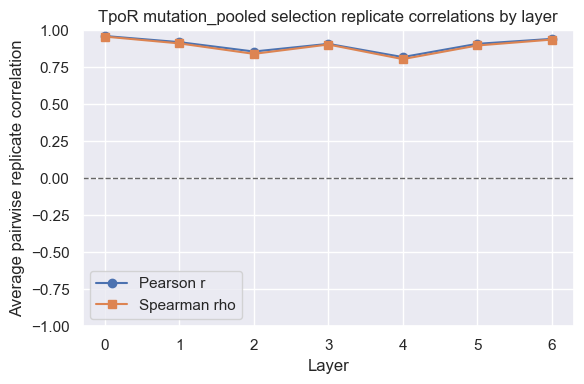

Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.


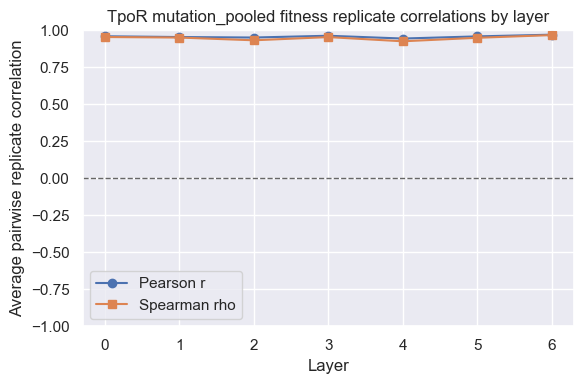

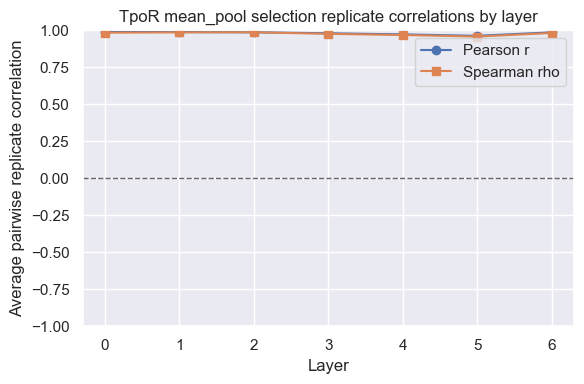

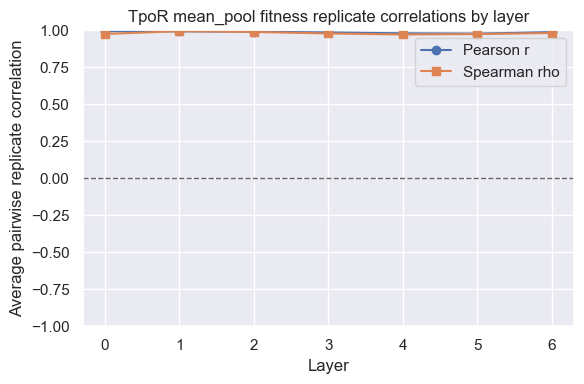

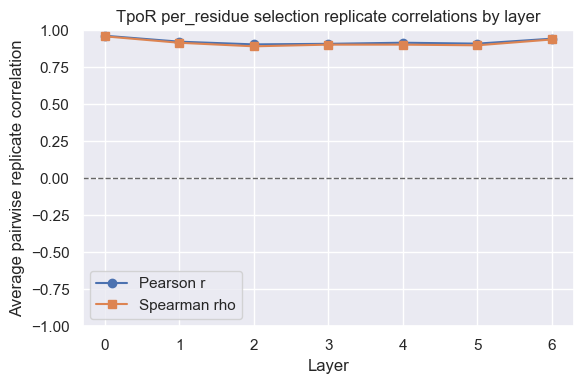

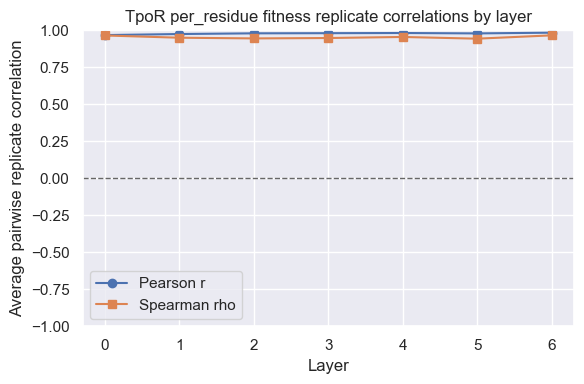

In [14]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="selection",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="fitness",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Representative Replicate Scatter Plots

Replicate scatter plots are delegated to `esmDMS.plot_rep_sel_comps()` and `esmDMS.plot_rep_fit_comps()`.

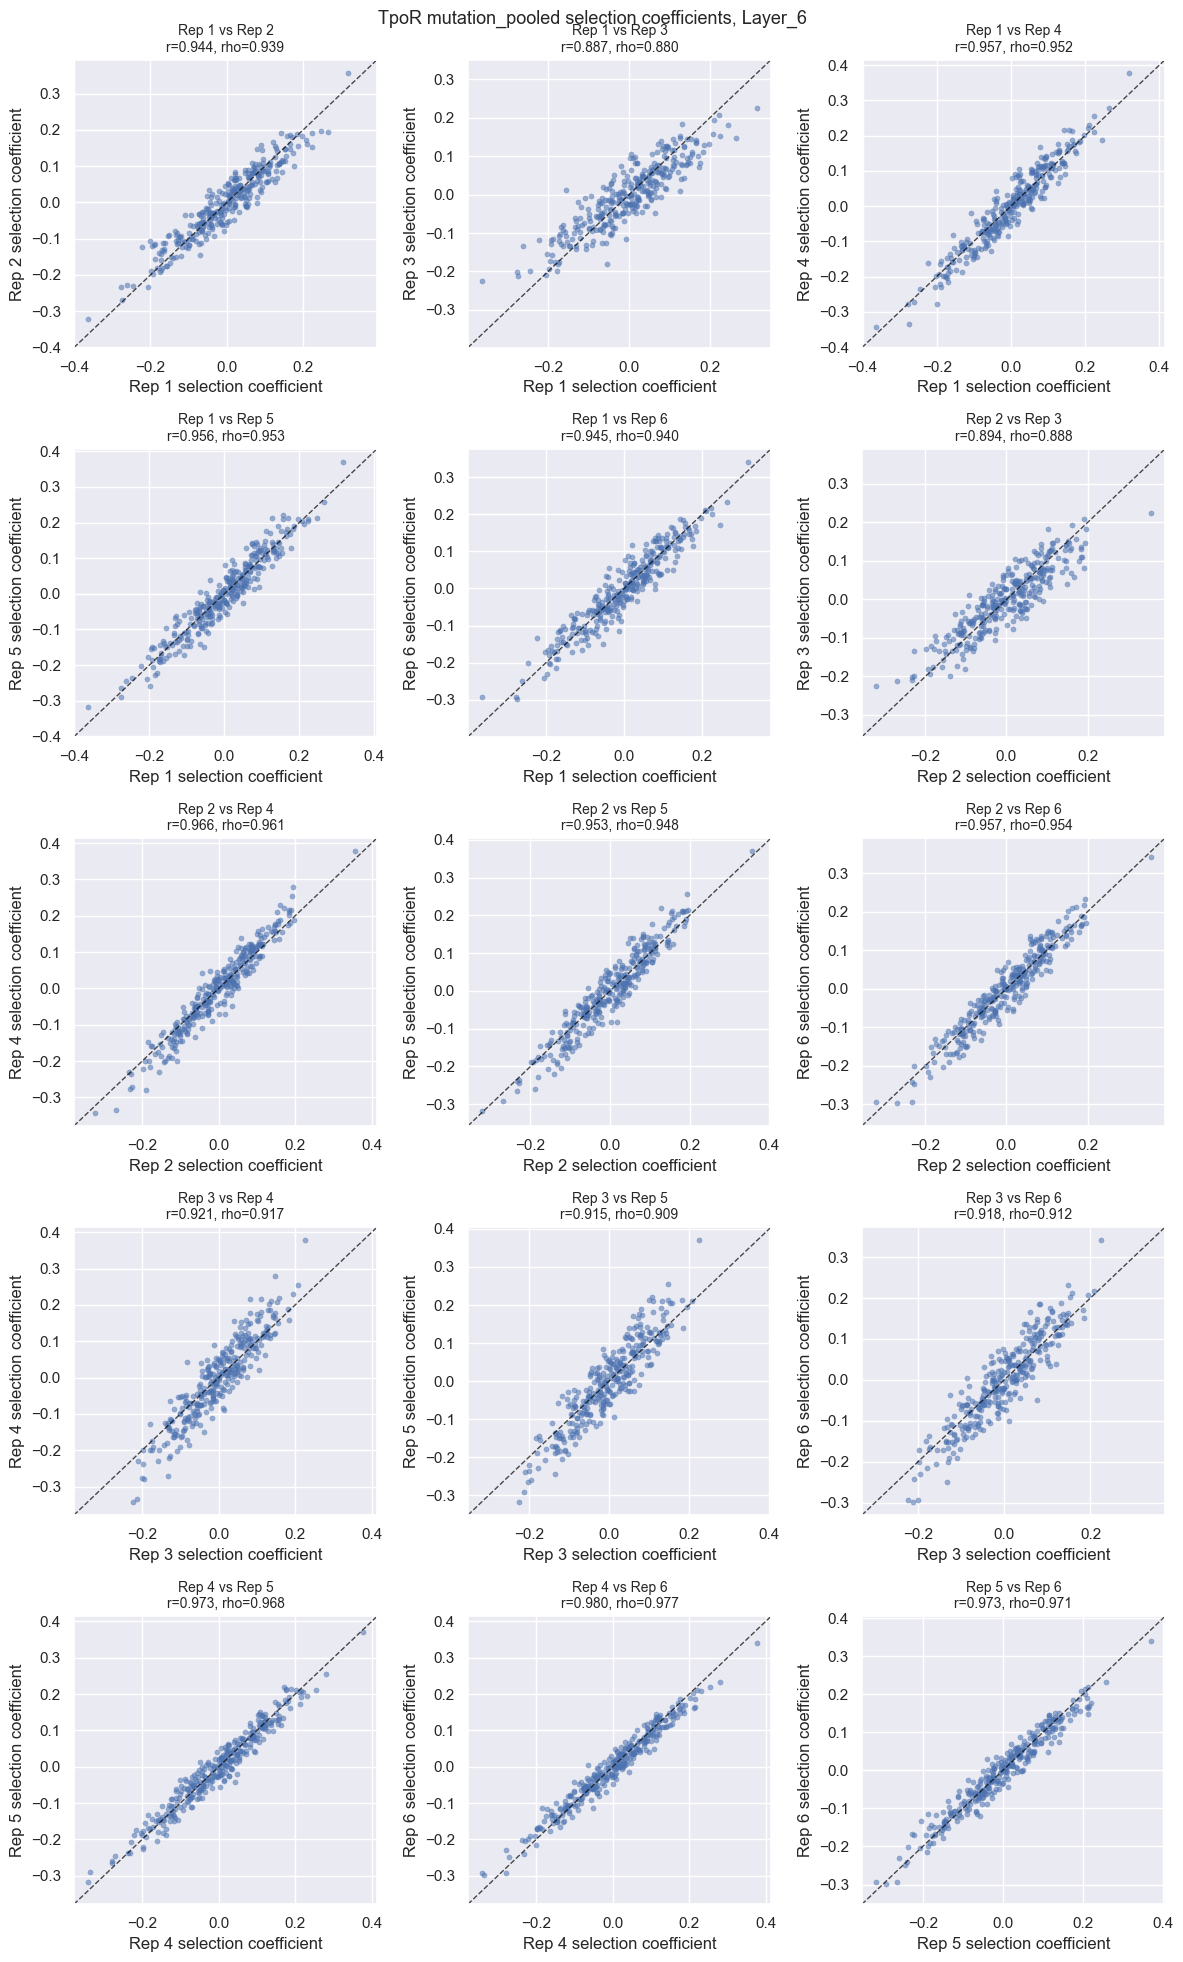

Inference plotting: dropping 1 sequence(s) with no mutation-site features.


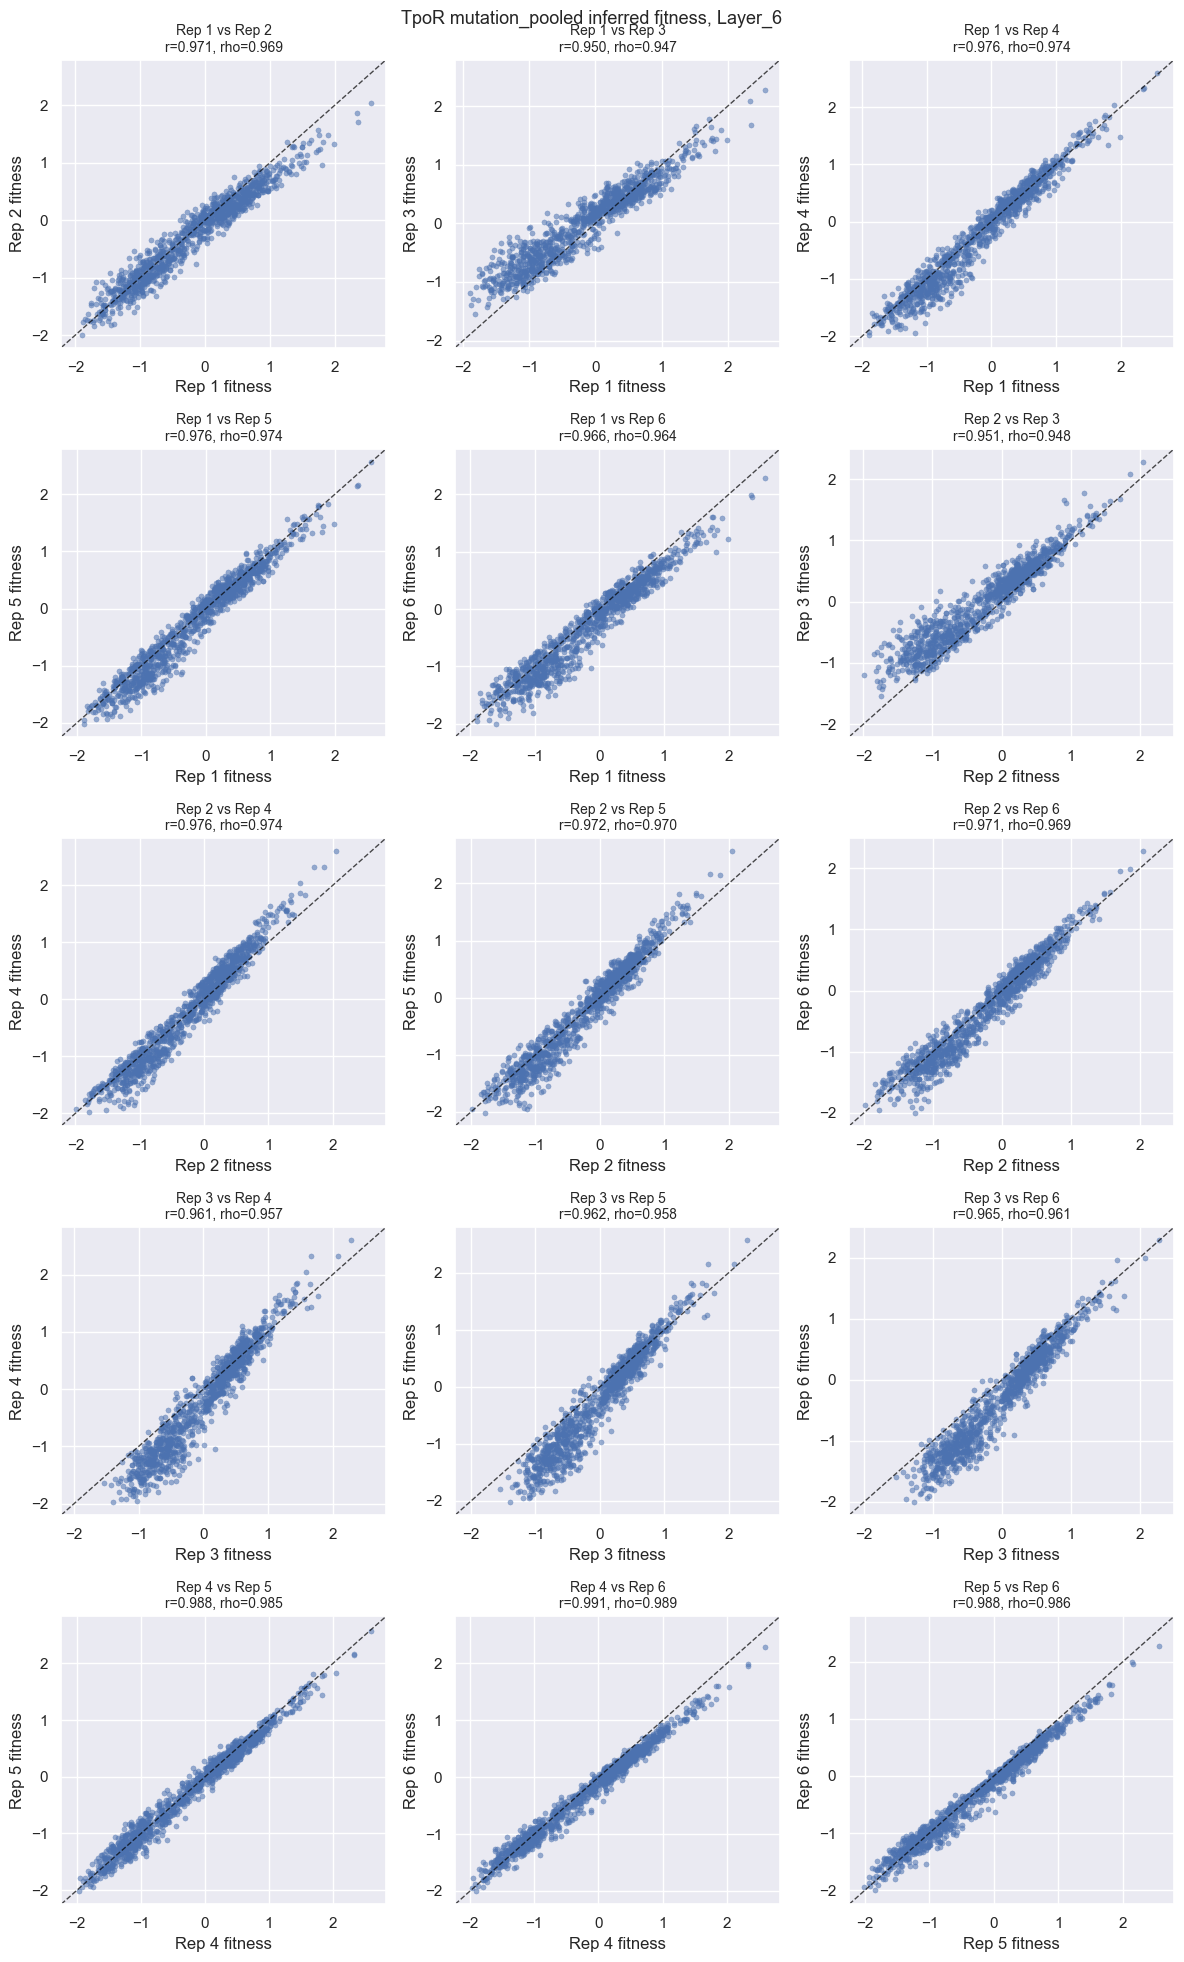

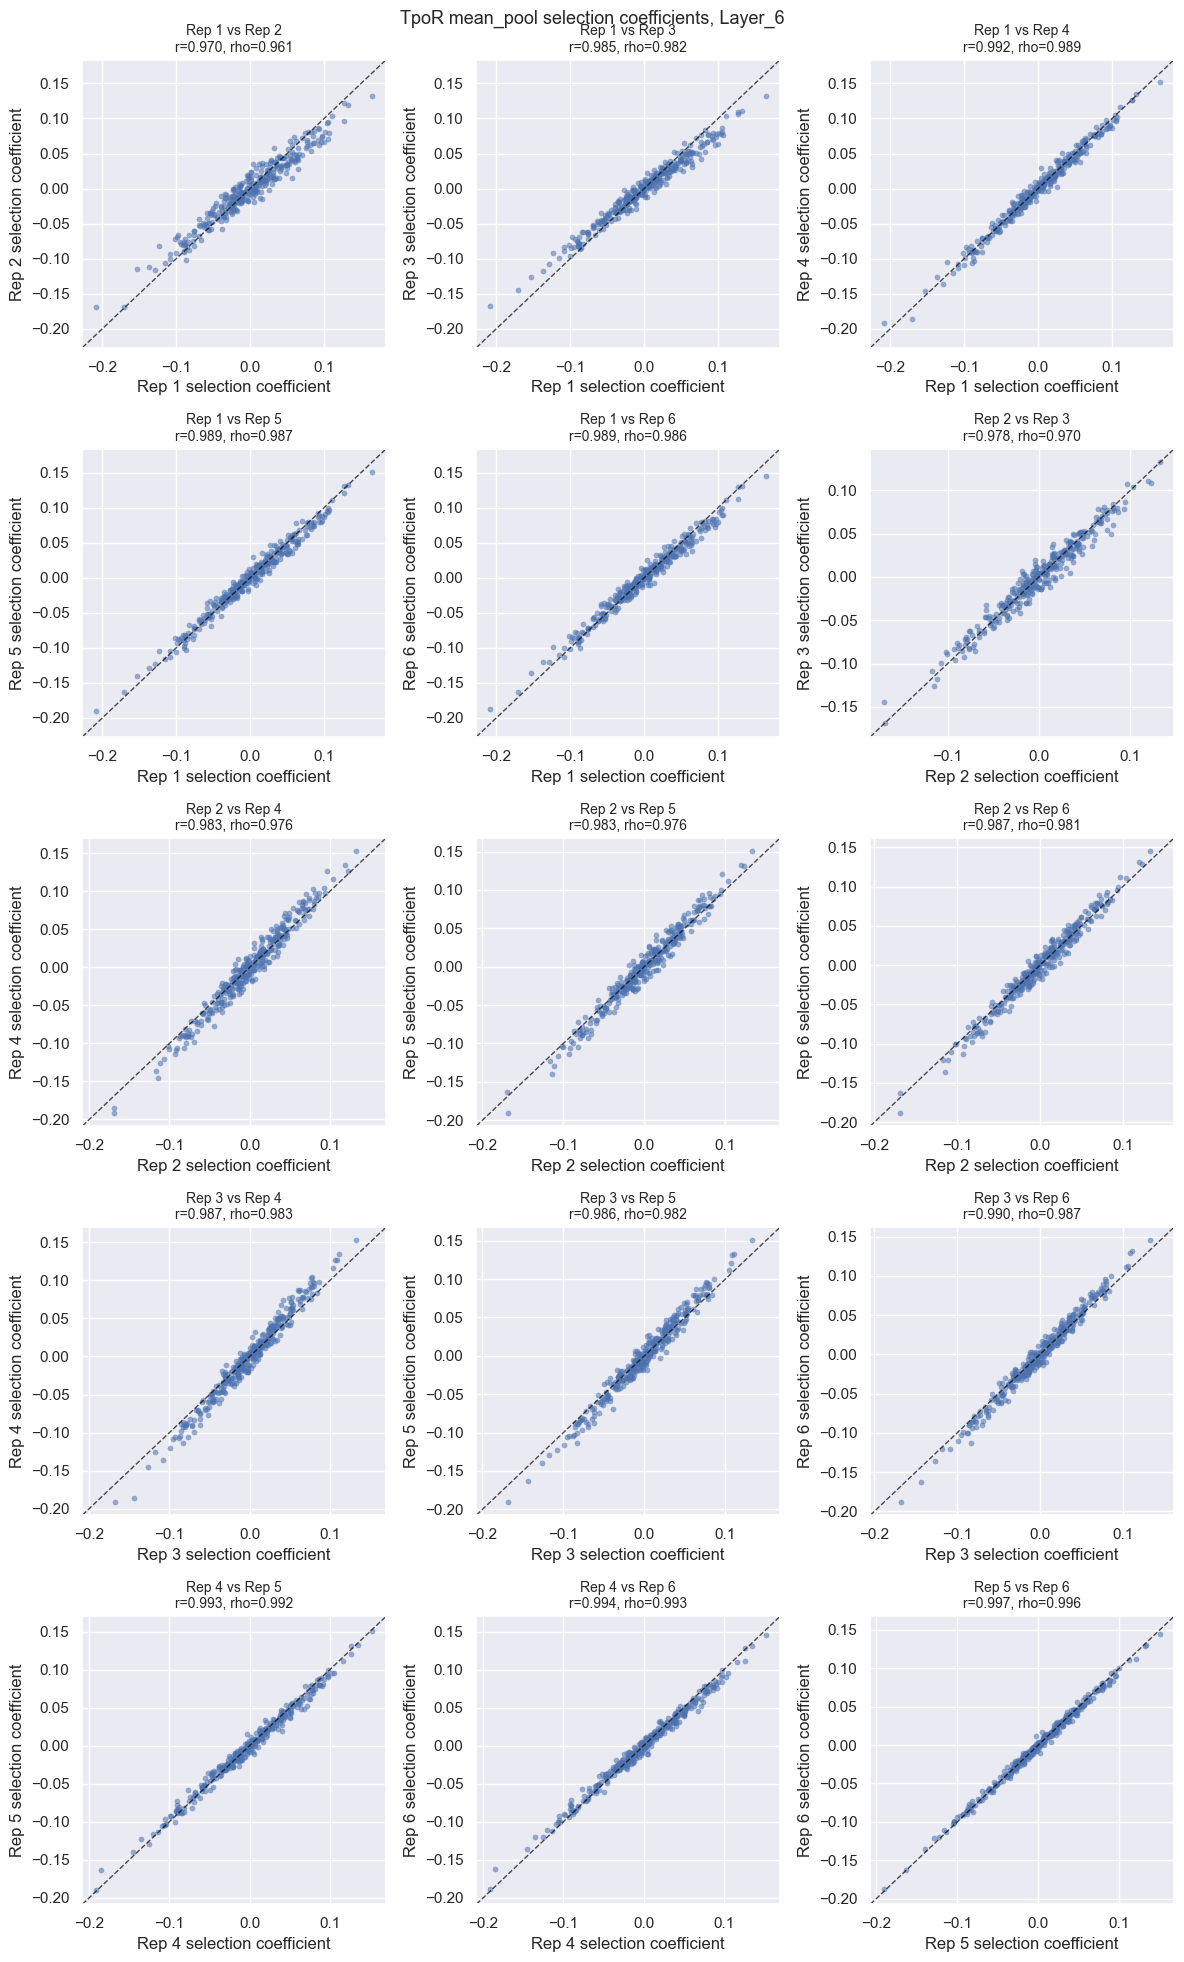

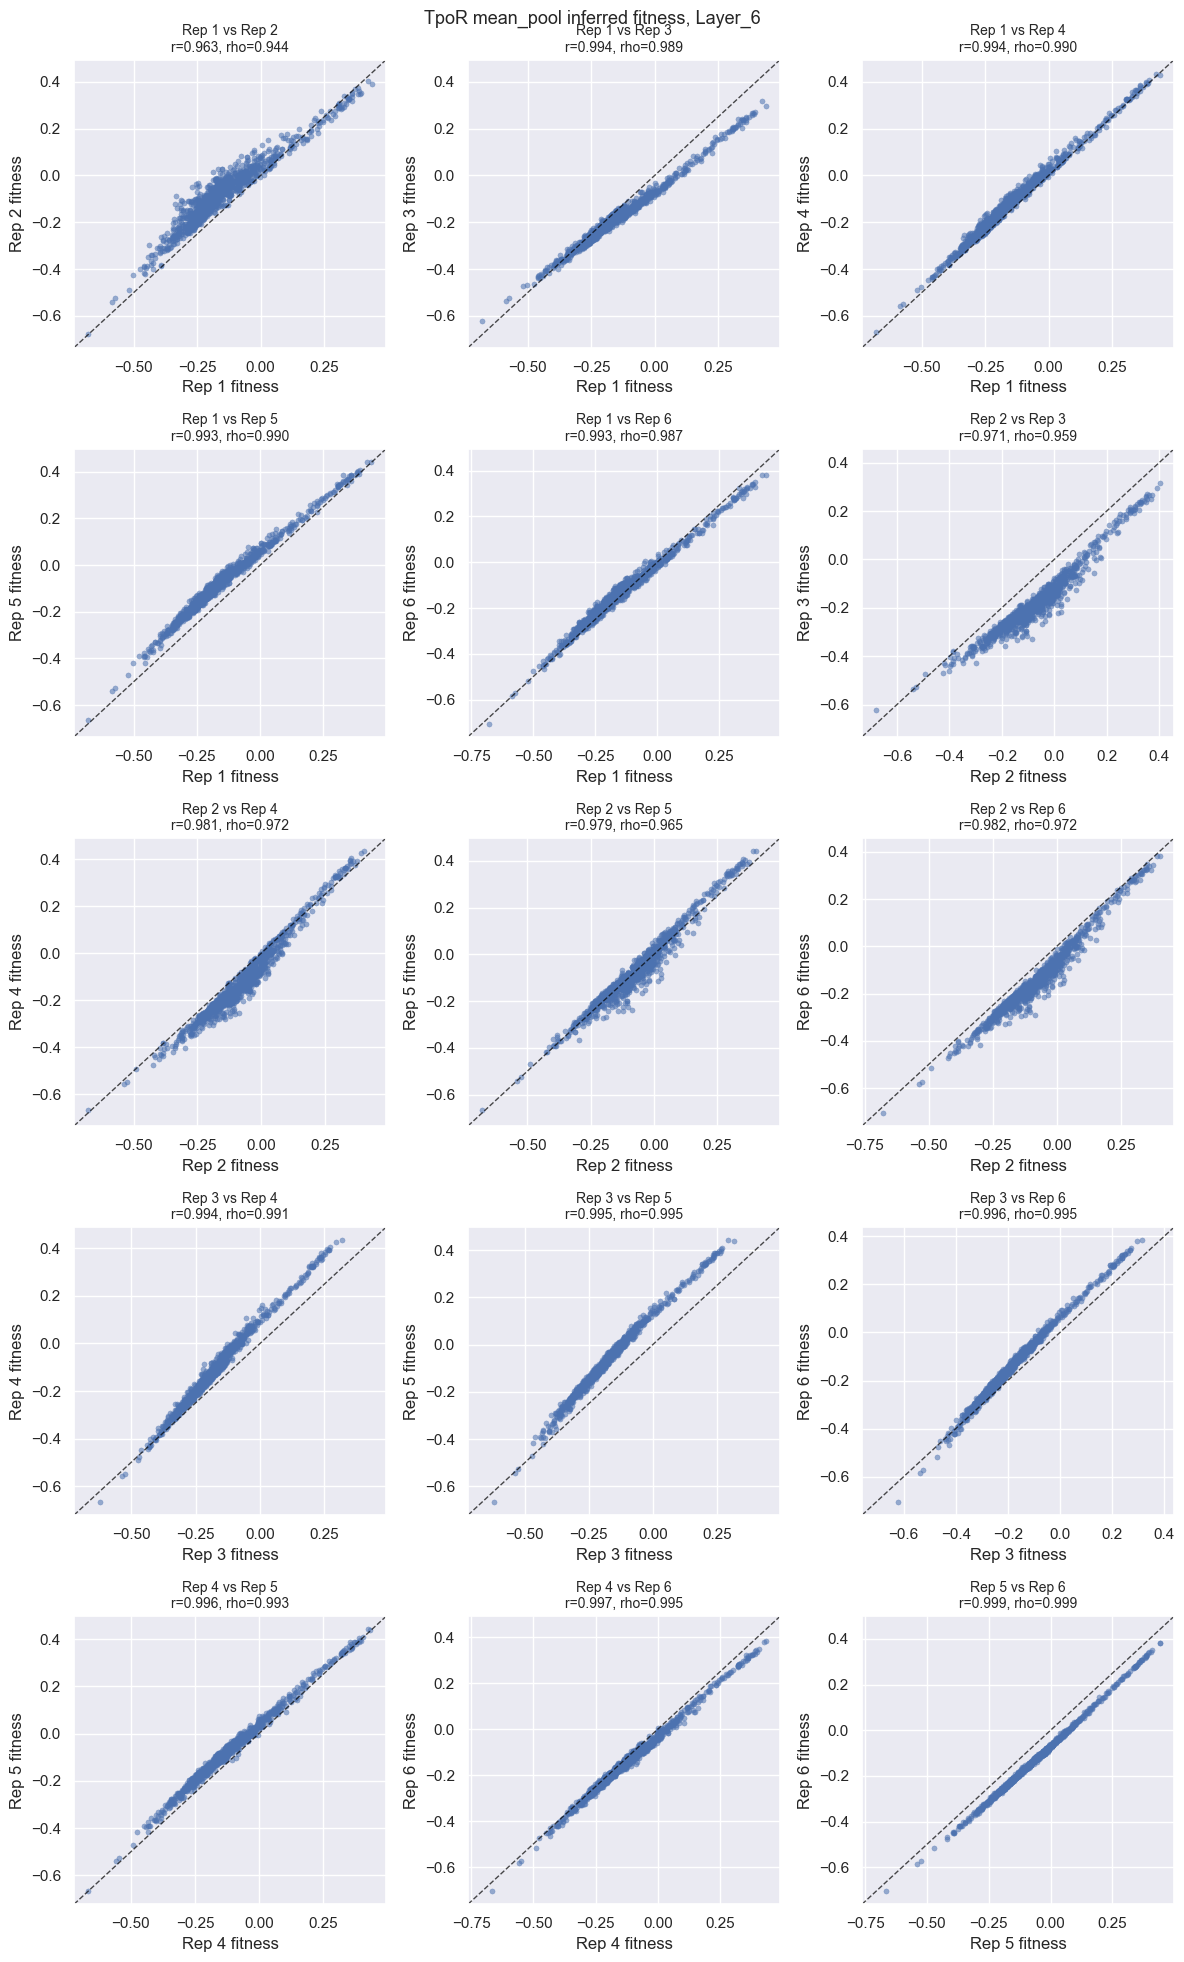

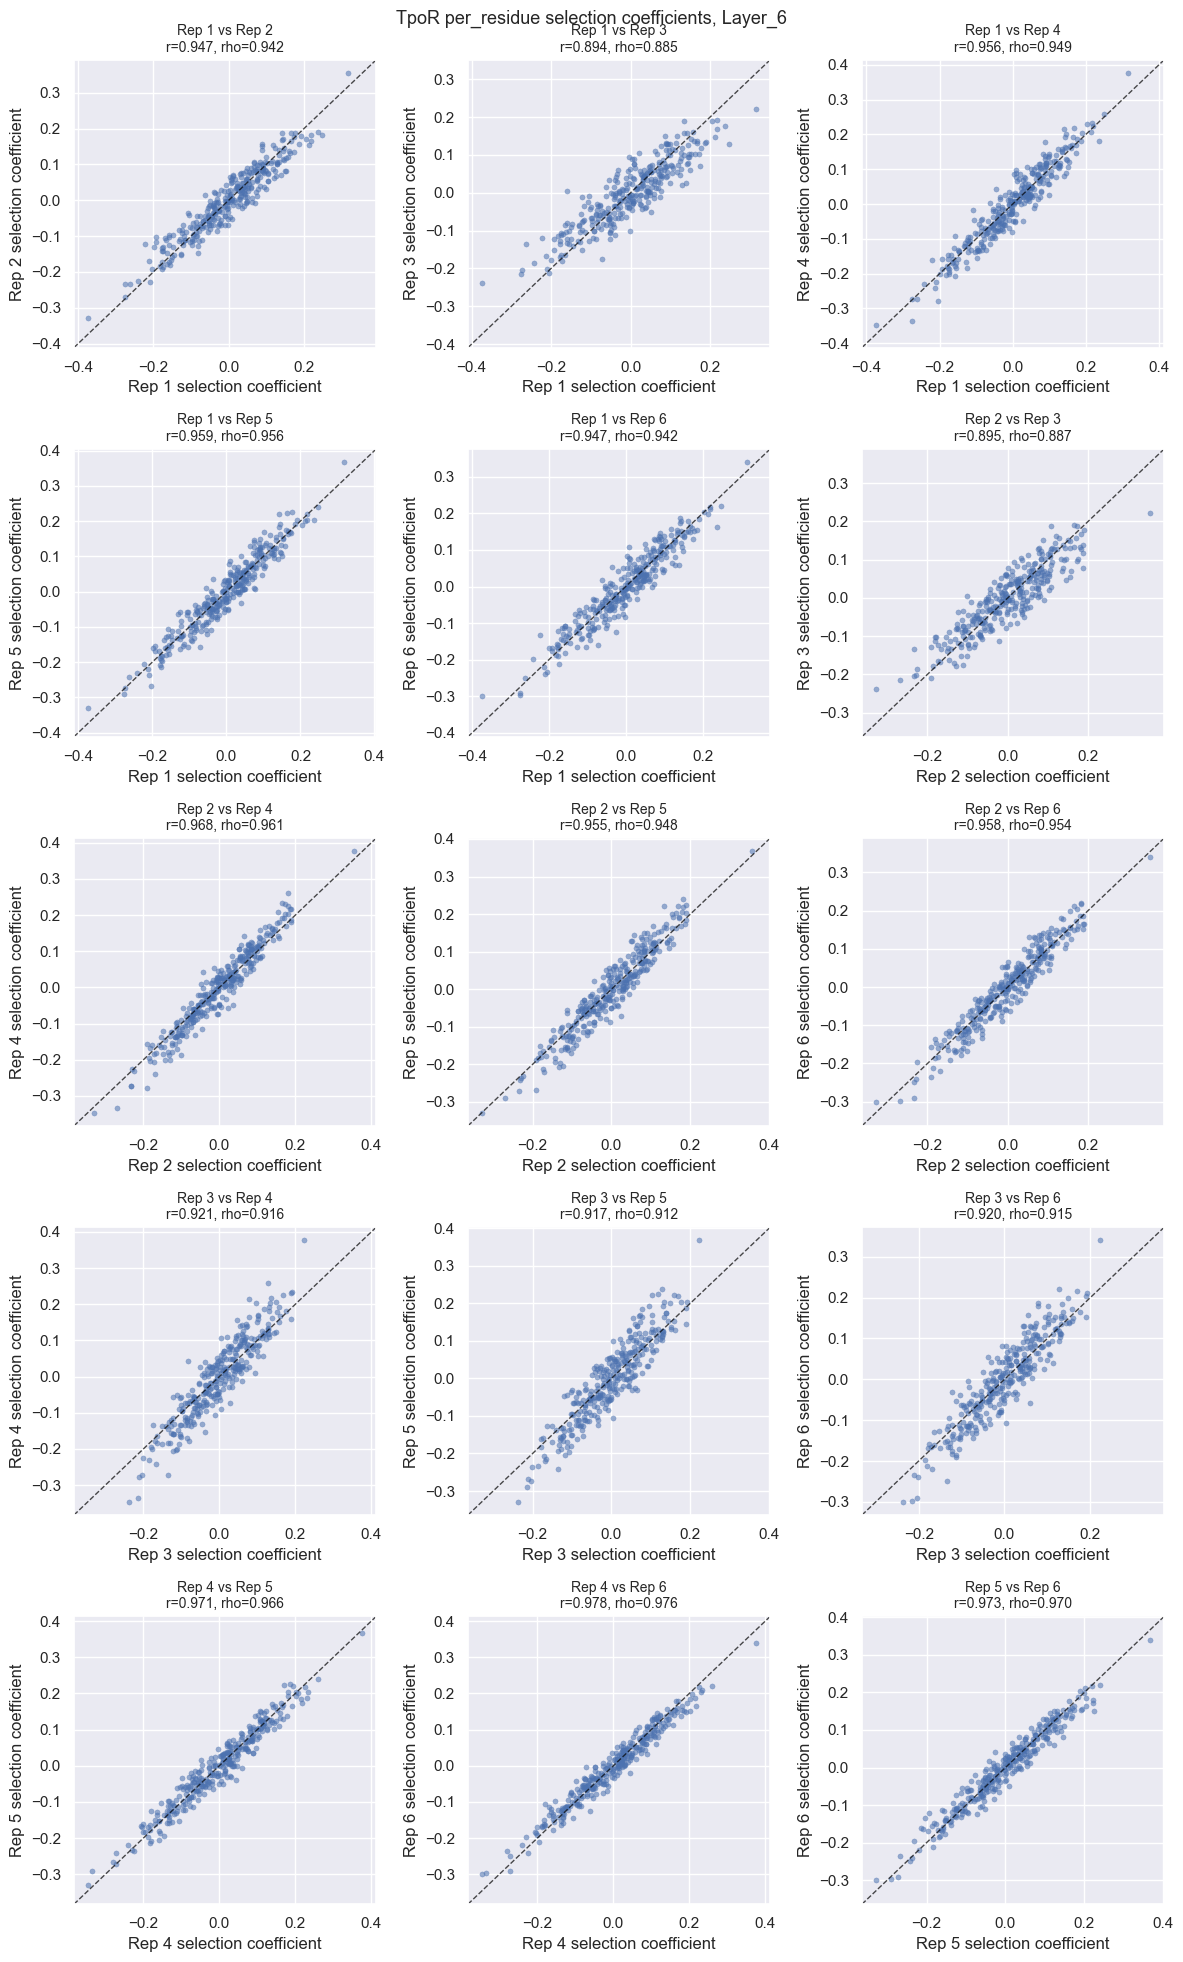

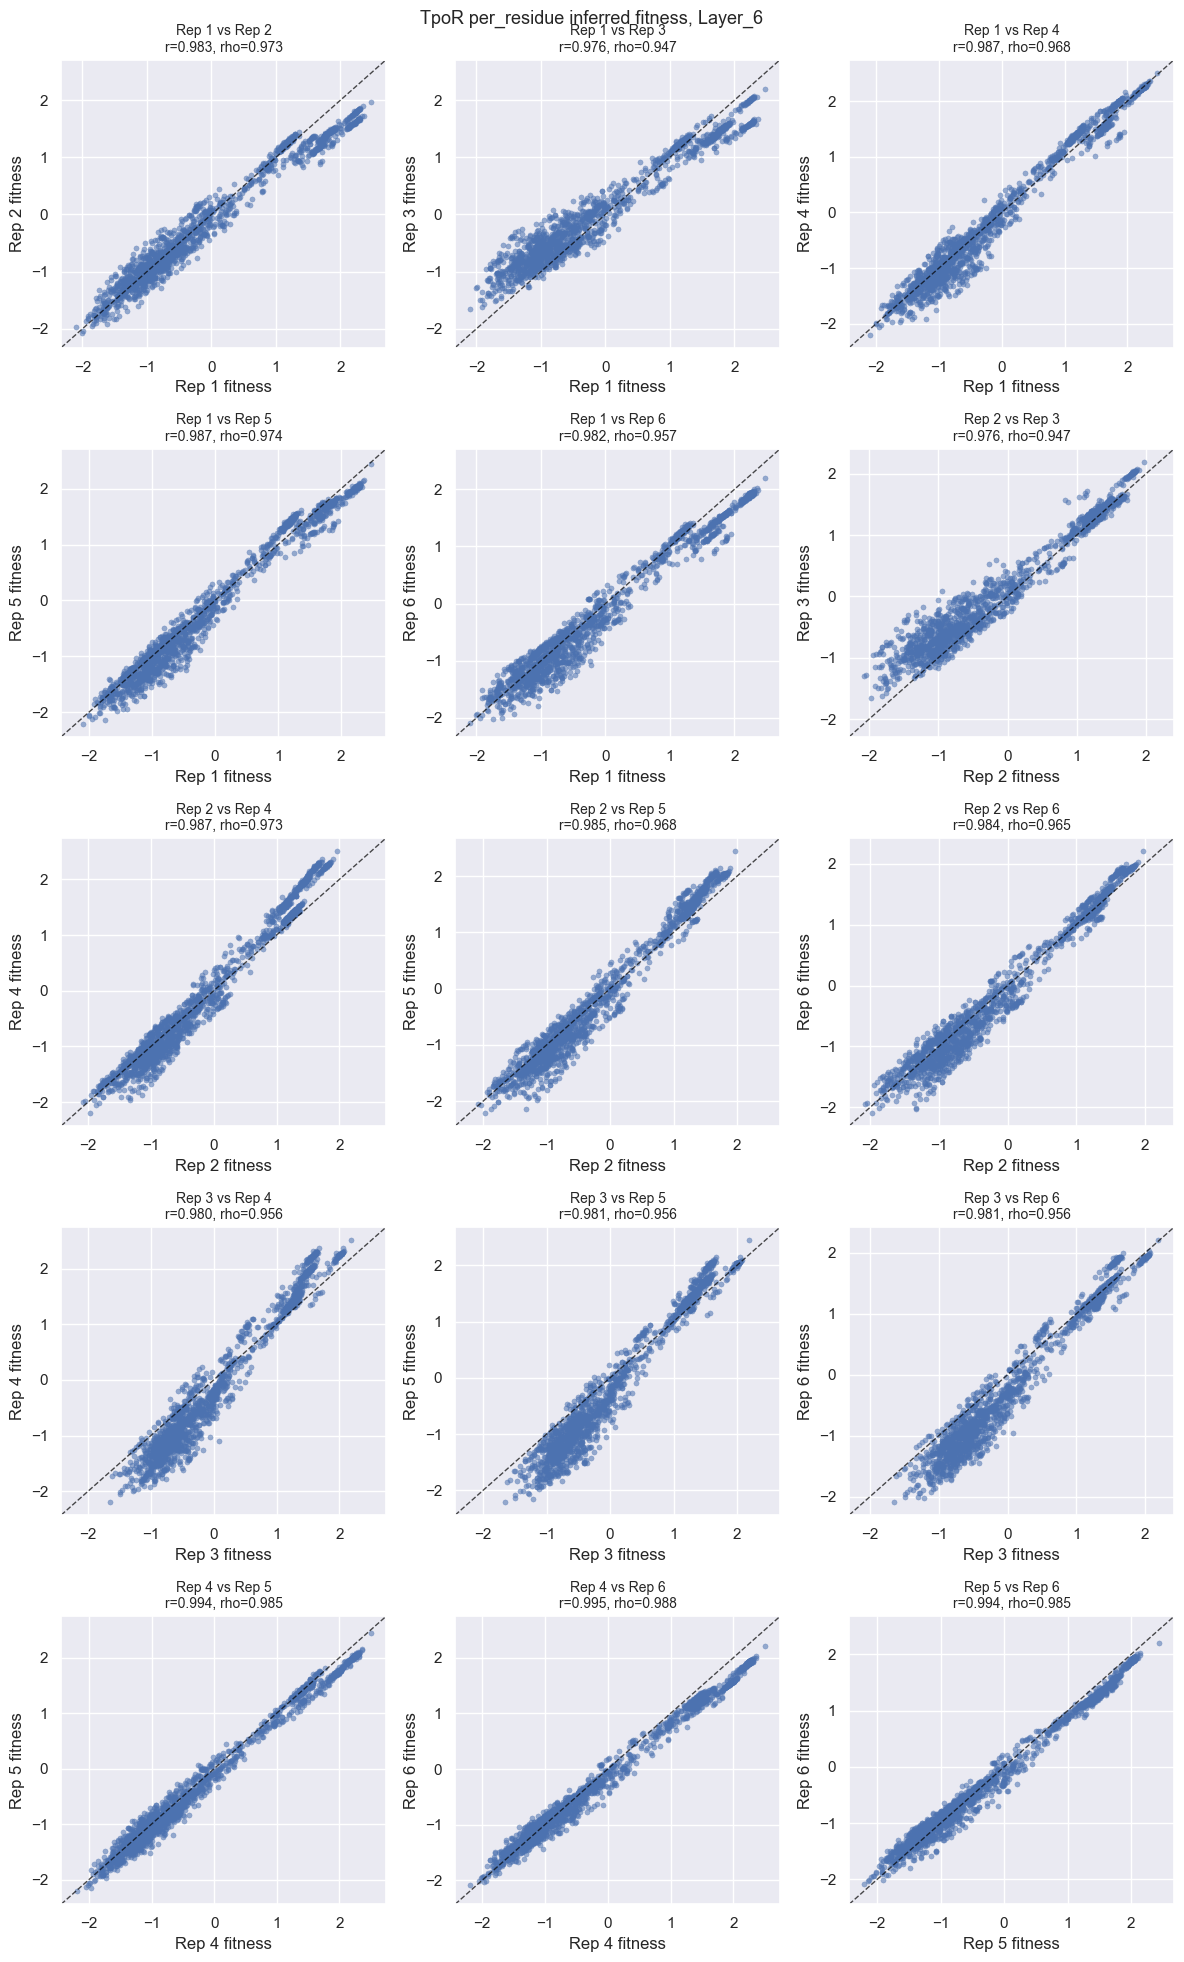

In [15]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig = runner.plot_rep_sel_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig = runner.plot_rep_fit_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Sparse Autoencoder Reconstruction Sweep

Train several SAE abstractions on one representative layer, visualize reconstruction quality in the notebook, and run inference for each SAE feature space. Plots are displayed only; they are not written to disk.

Training/loading SAE_nf64_sp0p0001 for TpoR, layer 6
SAE_nf64_sp0p0001 abstraction: dropping 1 sequence(s) with no mutation-site features.


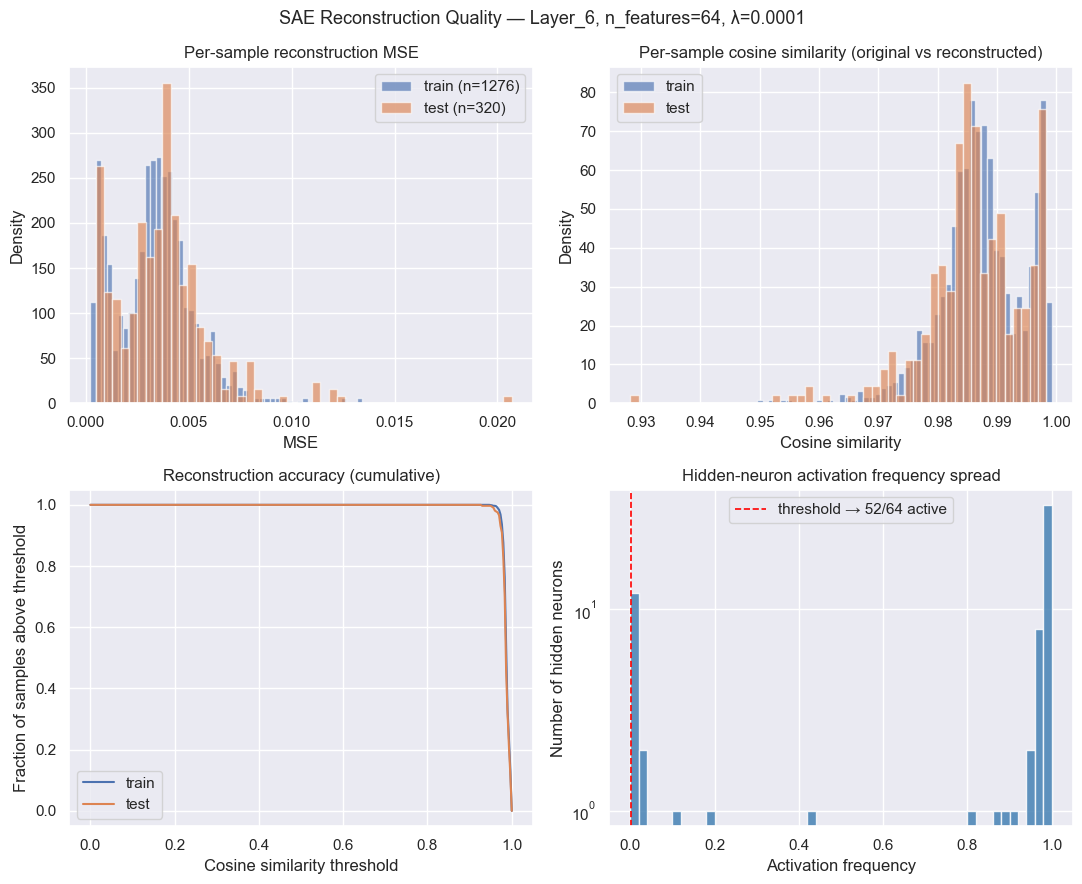

Training/loading SAE_nf128_sp0p001 for TpoR, layer 6
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.


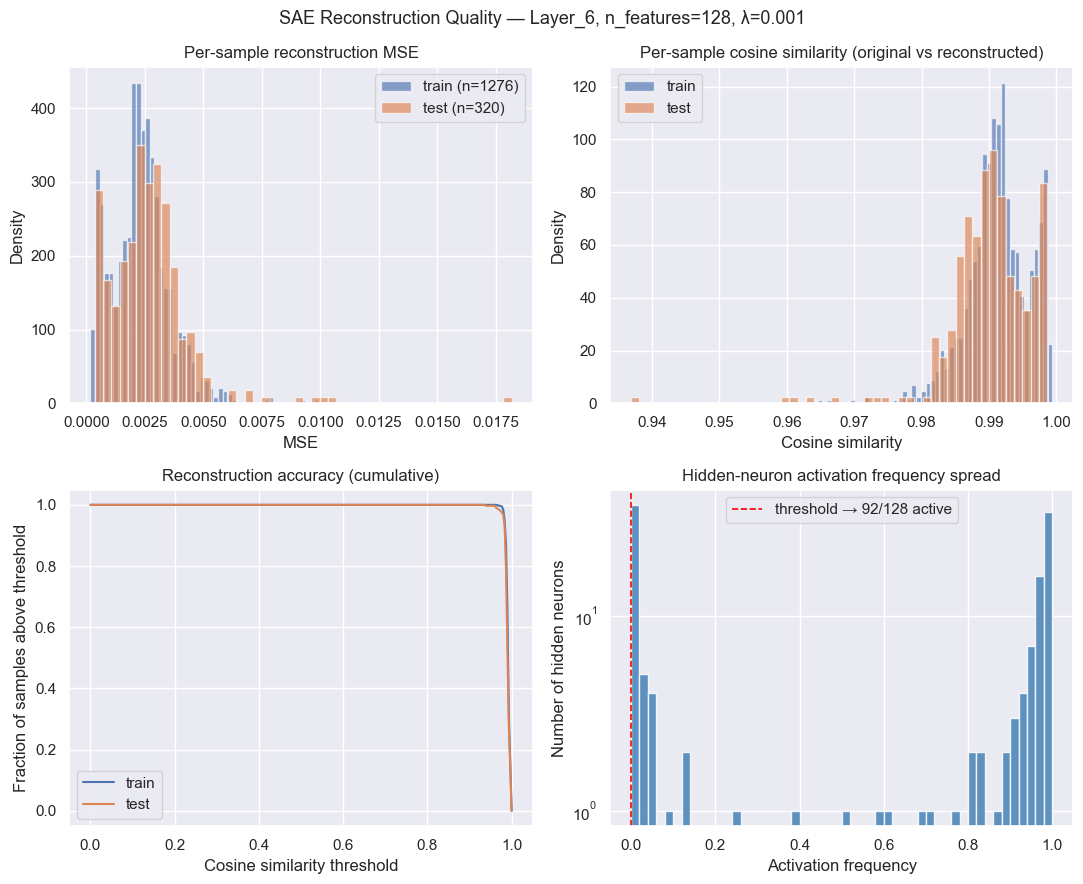

Training/loading SAE_nf256_sp0p001 for TpoR, layer 6
SAE_nf256_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.


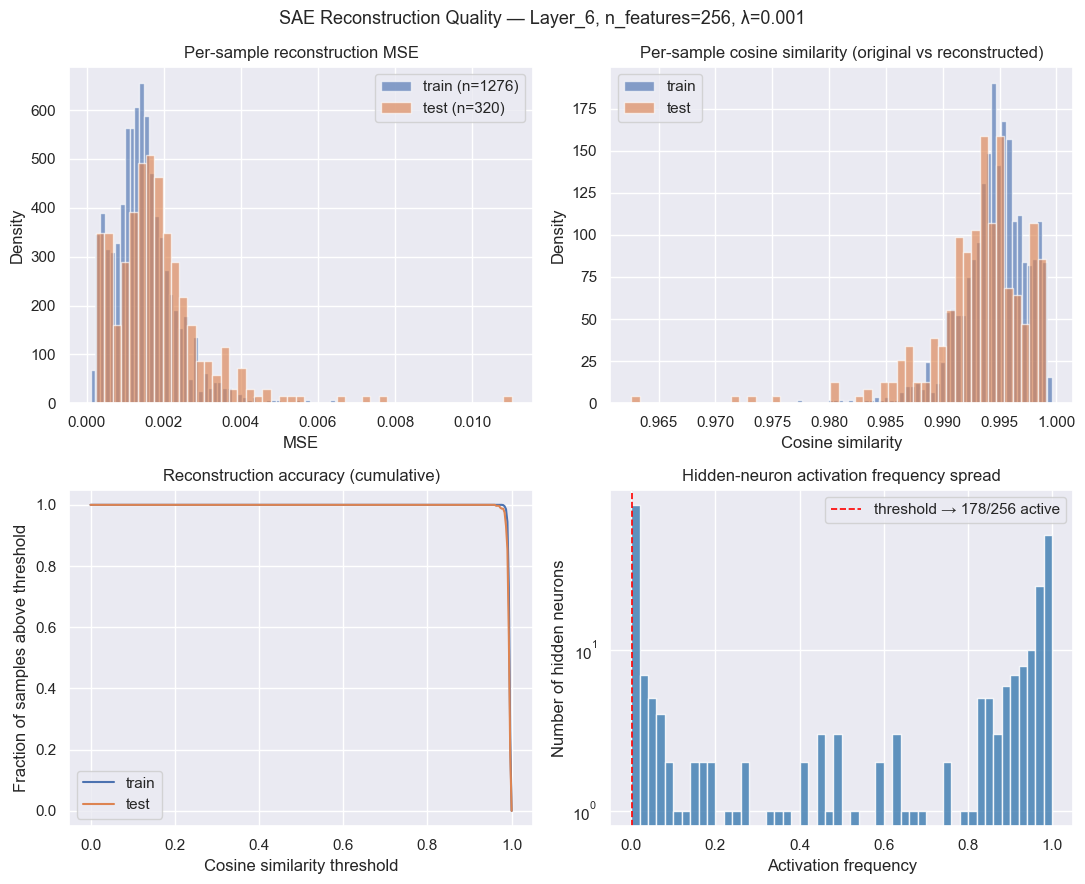

,dataset,layer,method,n_features,sparsity_coeff,epochs,batch_size
0,TpoR,6,SAE_nf64_sp0p0001,64,0.0001,50,128
1,TpoR,6,SAE_nf128_sp0p001,128,0.0010,50,128
2,TpoR,6,SAE_nf256_sp0p001,256,0.0010,50,128


In [16]:
SAE_TEST_LAYER = REPRESENTATIVE_LAYER
SAE_PARAM_GRID = [
    {"n_features": 64, "sparsity_coeff": 1e-4, "epochs": 50, "batch_size": 128},
    {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
    {"n_features": 256, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
]


def sae_method_name(params):
    sparsity = str(params["sparsity_coeff"]).replace(".", "p").replace("-", "m")
    return f"SAE_nf{params['n_features']}_sp{sparsity}"


sae_runs = []

for dataset, runner in runners.items():
    for params in SAE_PARAM_GRID:
        method = sae_method_name(params)
        sae_params = {**params, "norm_scheme": NORM_SCHEME}
        print(f"Training/loading {method} for {dataset}, layer {SAE_TEST_LAYER}")
        runner.create_feature_space(
            layer=SAE_TEST_LAYER,
            method=method,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=SAE_TEST_LAYER,
            abstraction_method=method,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        fig = runner.visualize_sae_reconstructions(
            layer=SAE_TEST_LAYER,
            method_params=sae_params,
            save=False,
        )
        display(fig)
        plt.close(fig)
        sae_runs.append({
            "dataset": dataset,
            "layer": SAE_TEST_LAYER,
            "method": method,
            **params,
        })

sae_run_table = pd.DataFrame(sae_runs)
sae_run_table


## SAE Fitness Comparisons

Compare inferred sequence fitness from the raw mutation-pooled embedding model against each SAE abstraction. Each scatter plot annotates the Spearman rho between methods.

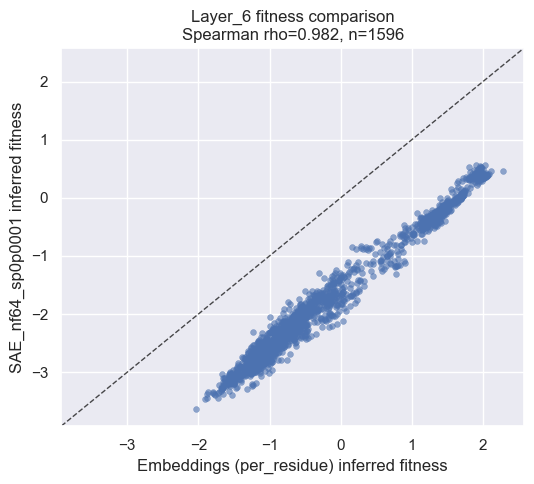

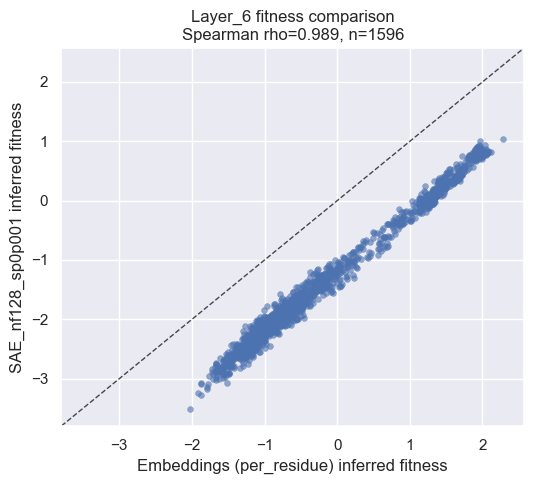

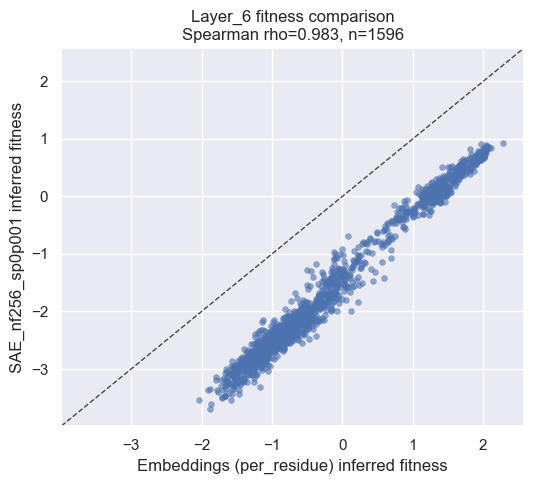

,dataset,layer,left_method,right_method,spearman_rho,n_sequences,n_features,sparsity_coeff,epochs,batch_size,norm_scheme
0,TpoR,6,none,SAE_nf64_sp0p0001,0.982117,1596,64,0.0001,50,128,none
1,TpoR,6,none,SAE_nf128_sp0p001,0.988569,1596,128,0.0010,50,128,none
2,TpoR,6,none,SAE_nf256_sp0p001,0.982965,1596,256,0.0010,50,128,none


In [17]:
sae_comparison_rows = []

for run in sae_runs:
    runner = runners[run["dataset"]]
    sae_params = {
        "n_features": run["n_features"],
        "sparsity_coeff": run["sparsity_coeff"],
        "epochs": run["epochs"],
        "batch_size": run["batch_size"],
        "norm_scheme": NORM_SCHEME,
    }
    fig, stats = runner.plot_fitness_method_comparison(
        layer=run["layer"],
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=run["method"],
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label=f"{ABSTRACTION_METHOD} ({EMBEDDING_TYPE})",
        right_label=run["method"],
    )
    display(fig)
    plt.close(fig)
    sae_comparison_rows.append({"dataset": run["dataset"], **stats, **sae_params})

sae_comparison_summary = pd.DataFrame(sae_comparison_rows)
sae_comparison_summary


## SAE Fitness Correlation Across Layers

Use one SAE setting across multiple layers and plot the Spearman rho between raw mutation-pooled inferred fitness and SAE-derived inferred fitness by layer. Adjust `SAE_LAYER_SWEEP_LAYERS` or `SAE_LAYER_SWEEP_PARAMS` to control runtime.

In [18]:
SAE_LAYER_SWEEP_LAYERS = LAYERS
SAE_LAYER_SWEEP_PARAMS = {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128}
SAE_LAYER_SWEEP_METHOD = sae_method_name(SAE_LAYER_SWEEP_PARAMS)
SAE_LAYER_SWEEP_METHOD


'SAE_nf128_sp0p001'

SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.


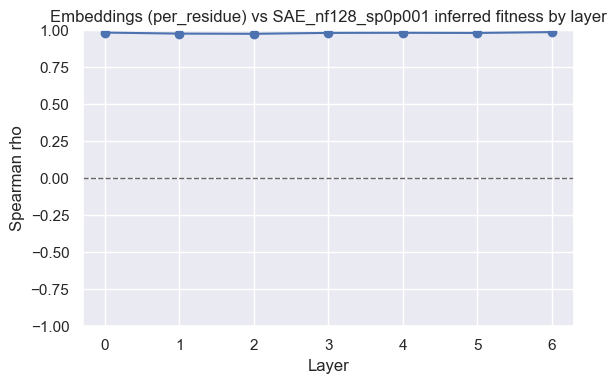

,dataset,layer,spearman_rho,n_sequences
0,TpoR,0,0.985327,1596
1,TpoR,1,0.978378,1596
2,TpoR,2,0.977094,1596
3,TpoR,3,0.983219,1596
4,TpoR,4,0.983891,1596
5,TpoR,5,0.982843,1596
6,TpoR,6,0.988569,1596


In [19]:
layer_sweep_summaries = []

for dataset, runner in runners.items():
    sae_params = {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME}
    for layer in SAE_LAYER_SWEEP_LAYERS:
        runner.create_feature_space(
            layer=layer,
            method=SAE_LAYER_SWEEP_METHOD,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=layer,
            abstraction_method=SAE_LAYER_SWEEP_METHOD,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )

    fig, corr_df = runner.plot_fitness_method_correlation_by_layer(
        layers=SAE_LAYER_SWEEP_LAYERS,
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=SAE_LAYER_SWEEP_METHOD,
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label=f"{ABSTRACTION_METHOD} ({EMBEDDING_TYPE})",
        right_label=SAE_LAYER_SWEEP_METHOD,
    )
    display(fig)
    plt.close(fig)
    corr_df.insert(0, "dataset", dataset)
    layer_sweep_summaries.append(corr_df)

sae_layer_sweep_summary = pd.concat(layer_sweep_summaries, ignore_index=True)
sae_layer_sweep_summary


## Method Fitness Consistency Ranking

Compare raw embedding choices and SAE abstractions by cross-replicate inferred-fitness Spearman rho. Higher mean rho means the feature space gives more consistent inferred fitness across replicate pairs.

Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.


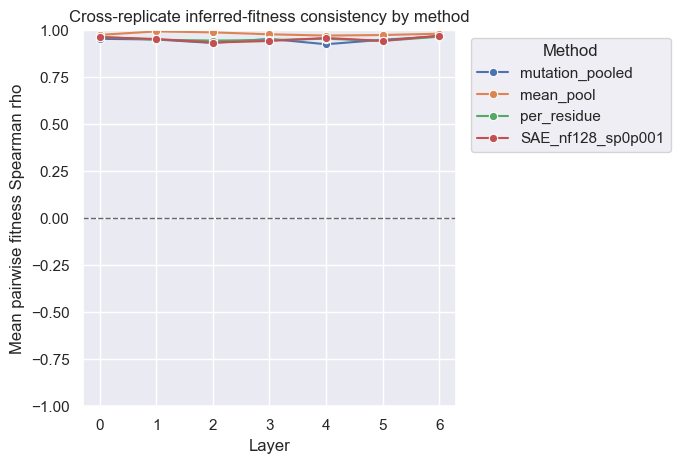

,dataset,label,layer,mean_spearman_rho,median_spearman_rho,n_pairs,n_sequences,embedding_type,abstraction_method
0,TpoR,mutation_pooled,0,0.955280,0.952393,15,1078,mutation_pooled,none
1,TpoR,mutation_pooled,1,0.951722,0.953142,15,1078,mutation_pooled,none
2,TpoR,mutation_pooled,2,0.933192,0.938069,15,1078,mutation_pooled,none
3,TpoR,mutation_pooled,3,0.954888,0.955480,15,1078,mutation_pooled,none
4,TpoR,mutation_pooled,4,0.926401,0.933840,15,1078,mutation_pooled,none
5,TpoR,mutation_pooled,5,0.950107,0.952635,15,1078,mutation_pooled,none
6,TpoR,mutation_pooled,6,0.968363,0.969035,15,1078,mutation_pooled,none
7,TpoR,mean_pool,0,0.976128,0.975639,15,1079,mean_pool,none
8,TpoR,mean_pool,1,0.994753,0.994346,15,1079,mean_pool,none
9,TpoR,mean_pool,2,0.989578,0.990062,15,1079,mean_pool,none


In [20]:
METHOD_CONSISTENCY_SPECS = [
    {
        "label": "mutation_pooled",
        "embedding_type": "mutation_pooled",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "mean_pool",
        "embedding_type": "mean_pool",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "per_residue",
        "embedding_type": "per_residue",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": SAE_LAYER_SWEEP_METHOD,
        "embedding_type": EMBEDDING_TYPE,
        "abstraction_method": SAE_LAYER_SWEEP_METHOD,
        "abstraction_params": {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME},
    },
]

consistency_summaries = []
consistency_details = []

for dataset, runner in runners.items():
    fig, summary_df, detail_df = runner.analyze_method_fitness_consistency_by_layer(
        layers=LAYERS,
        method_specs=METHOD_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    detail_df.insert(0, "dataset", dataset)
    consistency_summaries.append(summary_df)
    consistency_details.append(detail_df)

method_consistency_summary = pd.concat(consistency_summaries, ignore_index=True)
method_consistency_detail = pd.concat(consistency_details, ignore_index=True)
method_consistency_summary


In [21]:
method_consistency_ranking = (
    method_consistency_summary
    .groupby(["dataset", "label", "embedding_type", "abstraction_method"], as_index=False)
    .agg(
        mean_layer_rho=("mean_spearman_rho", "mean"),
        median_layer_rho=("mean_spearman_rho", "median"),
        best_layer_rho=("mean_spearman_rho", "max"),
        worst_layer_rho=("mean_spearman_rho", "min"),
        n_layers=("layer", "nunique"),
    )
    .sort_values(["dataset", "mean_layer_rho"], ascending=[True, False])
)
method_consistency_ranking


,dataset,label,embedding_type,abstraction_method,mean_layer_rho,median_layer_rho,best_layer_rho,worst_layer_rho,n_layers
1,TpoR,mean_pool,mean_pool,none,0.981448,0.979325,0.994753,0.972503,7
3,TpoR,per_residue,per_residue,none,0.953893,0.950585,0.966551,0.944124,7
0,TpoR,SAE_nf128_sp0p001,per_residue,SAE_nf128_sp0p001,0.953428,0.954234,0.972329,0.935306,7
2,TpoR,mutation_pooled,mutation_pooled,none,0.948565,0.951722,0.968363,0.926401,7


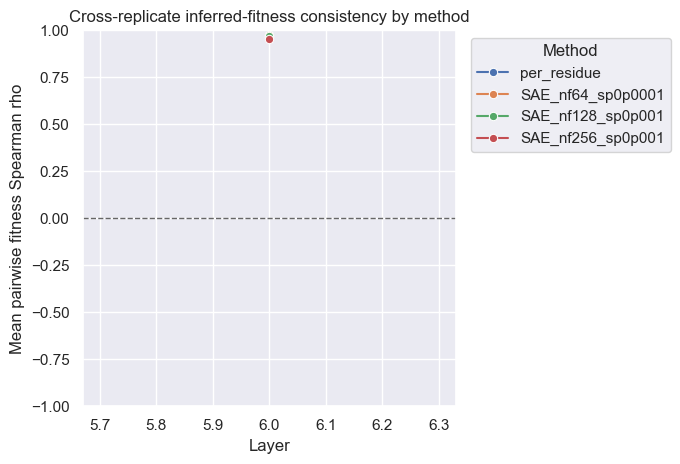

,dataset,label,layer,mean_spearman_rho,median_spearman_rho,n_pairs,n_sequences,embedding_type,abstraction_method
1,TpoR,SAE_nf64_sp0p0001,6,0.974165,0.974013,15,1596,per_residue,SAE_nf64_sp0p0001
2,TpoR,SAE_nf128_sp0p001,6,0.972329,0.972619,15,1596,per_residue,SAE_nf128_sp0p001
0,TpoR,per_residue,6,0.966551,0.967847,15,1596,per_residue,none
3,TpoR,SAE_nf256_sp0p001,6,0.954041,0.956345,15,1596,per_residue,SAE_nf256_sp0p001


In [22]:
SAE_GRID_CONSISTENCY_SPECS = [
    {
        "label": "per_residue",
        "embedding_type": "per_residue",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    *[
        {
            "label": sae_method_name(params),
            "embedding_type": EMBEDDING_TYPE,
            "abstraction_method": sae_method_name(params),
            "abstraction_params": {**params, "norm_scheme": NORM_SCHEME},
        }
        for params in SAE_PARAM_GRID
    ],
]

sae_grid_consistency_summaries = []

for dataset, runner in runners.items():
    fig, summary_df, _ = runner.analyze_method_fitness_consistency_by_layer(
        layers=[SAE_TEST_LAYER],
        method_specs=SAE_GRID_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    sae_grid_consistency_summaries.append(summary_df)

sae_grid_consistency_summary = pd.concat(sae_grid_consistency_summaries, ignore_index=True)
sae_grid_consistency_summary.sort_values(["dataset", "mean_spearman_rho"], ascending=[True, False])


## Shuffled-Frequency Control

This notebook does not implement shuffled controls locally.

In [23]:
# TODO(esmDMS.py): add a class method for shuffled-frequency controls that shuffles
# within each (Replicate, Generation), reruns inference, and returns InferenceResult
# objects compatible with the plotting methods above.

## Sparse Autoencoder Hyperparameter Sweep

Sweep SAE hidden-layer size, ESM embedding layer, embedding type, and SAE sparsity type. The scoring is staged: Tier 1 uses cheap reconstruction, sparsity, entropy, and seed-stability metrics; Tier 2 runs downstream inference only for Tier 1 survivors and scores replicate reliability.


In [ ]:
from itertools import product

import numpy as np
import torch
from scipy.stats import pearsonr, spearmanr

SAE_SWEEP_HIDDEN_SIZES = [1024, 2048, 4096, 8192]
SAE_SWEEP_LAYERS = LAYERS
SAE_SWEEP_EMBEDDING_TYPES = RAW_EMBEDDING_TYPES
SAE_SWEEP_TYPE_CONFIGS = [
    {"sparsity_mode": "normal", "k": None},
    {"sparsity_mode": "topk", "k": 32},
    {"sparsity_mode": "batchtopk", "k": 32},
]
SAE_SWEEP_SEEDS = [42, 43]
SAE_SWEEP_PRIMARY_SEED = SAE_SWEEP_SEEDS[0]
SAE_SWEEP_SPARSITY_COEFF = 1e-3
SAE_SWEEP_EPOCHS = 50
SAE_SWEEP_BATCH_SIZE = 128
SAE_SWEEP_ACTIVITY_THRESHOLD = 1e-3
SAE_SWEEP_DEAD_FREQUENCY_MAX = 0.01
SAE_SWEEP_DENSE_FREQUENCY_MIN = 0.20
SAE_SWEEP_TRAIN_FRAC = 0.8
SAE_SWEEP_FORCE_RETRAIN = False
SAE_SWEEP_TIER1_KEEP_FRAC = 0.35
SAE_SWEEP_TOP_HIT_FRAC = 0.05
SAE_SWEEP_TOP_HIT_MIN_K = 10


def sae_sweep_type_label(sparsity_mode, k):
    if sparsity_mode == "normal":
        return "normal"
    return f"{sparsity_mode}_k{k}"


def sae_sweep_run_label(seed):
    return f"seed{seed}"


def sae_sweep_candidate_id(embedding_type, layer, n_features, sparsity_mode, k):
    return f"{embedding_type}|layer{layer}|hidden{n_features}|{sae_sweep_type_label(sparsity_mode, k)}"


def sae_sweep_method_name(n_features, sparsity_mode, k, seed, sparsity_coeff=SAE_SWEEP_SPARSITY_COEFF):
    sparsity = str(sparsity_coeff).replace(".", "p").replace("-", "m")
    return f"SAE_{sae_sweep_type_label(sparsity_mode, k)}_{sae_sweep_run_label(seed)}_nf{n_features}_sp{sparsity}"


def sae_sweep_params(n_features, sparsity_mode, k, seed):
    params = {
        "n_features": n_features,
        "sparsity_coeff": SAE_SWEEP_SPARSITY_COEFF,
        "epochs": SAE_SWEEP_EPOCHS,
        "batch_size": SAE_SWEEP_BATCH_SIZE,
        "train_frac": SAE_SWEEP_TRAIN_FRAC,
        "activity_threshold": SAE_SWEEP_ACTIVITY_THRESHOLD,
        "norm_scheme": NORM_SCHEME,
        "sparsity_mode": sparsity_mode,
        "seed": seed,
        "run_label": sae_sweep_run_label(seed),
    }
    if k is not None:
        params["k"] = k
    return params


def sae_sweep_viz_path(runner, layer, embedding_type, params):
    return runner._sae_viz_path(
        layer,
        params["n_features"],
        params["sparsity_coeff"],
        embedding_type,
        params.get("sparsity_mode", "normal"),
        params.get("k"),
        params.get("run_label"),
    )


def sae_sweep_model_path(runner, layer, embedding_type, params):
    return runner._sae_model_path(
        layer,
        params["n_features"],
        params["sparsity_coeff"],
        embedding_type,
        params.get("sparsity_mode", "normal"),
        params.get("k"),
        params.get("run_label"),
    )


def ensure_sae_sweep_feature_space(runner, layer, embedding_type, method, params):
    feature_path = runner._feature_path(method, layer, embedding_type)
    viz_path = sae_sweep_viz_path(runner, layer, embedding_type, params)
    if not SAE_SWEEP_FORCE_RETRAIN and feature_path.is_file() and viz_path.is_file():
        return runner._load_pickle(feature_path)

    embeddings = runner.load_embeddings(layer, embedding_type)
    _, embeddings = runner._drop_missing_features(None, embeddings, f"{method} sweep")
    if embedding_type == "per_residue":
        embeddings, _ = runner._expand_per_residue_feature_vectors(
            embeddings,
            runner.sequence_to_mutation_sites,
        )
    runner._require_vector_features(embeddings, f"{method} sweep with embedding_type={embedding_type!r}")

    internal_params = dict(params)
    internal_params.setdefault("_layer", layer)
    internal_params.setdefault("_embedding_type", embedding_type)
    features = runner._create_feature_space(embeddings, method, internal_params)

    if runner._use_memory():
        runner.sequence_to_features[runner._feature_key(method, layer, embedding_type)] = features
    if runner._use_disk():
        runner._save_pickle(features, feature_path)
    return features


def normalized_entropy(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) <= 1:
        return np.nan
    p = values / values.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def reconstruction_r2(x_original, x_reconstructed, idx):
    idx = np.asarray(idx, dtype=int)
    if len(idx) == 0:
        return np.nan
    x = np.asarray(x_original)[idx]
    x_hat = np.asarray(x_reconstructed)[idx]
    sse = float(np.square(x - x_hat).sum())
    sst = float(np.square(x - x.mean(axis=0, keepdims=True)).sum())
    if sst <= 0:
        return np.nan
    return 1.0 - sse / sst


def decoder_feature_stability(model_paths):
    decoder_mats = []
    for model_path in model_paths:
        if not model_path or not Path(model_path).is_file():
            continue
        state = torch.load(model_path, map_location="cpu")
        weight = state["model_state_dict"]["decoder.weight"].detach().float().numpy()
        weight = weight / np.clip(np.linalg.norm(weight, axis=0, keepdims=True), 1e-8, None)
        decoder_mats.append(weight)
    if len(decoder_mats) < 2:
        return np.nan

    scores = []
    for left_idx in range(len(decoder_mats)):
        for right_idx in range(left_idx + 1, len(decoder_mats)):
            similarity = np.abs(decoder_mats[left_idx].T @ decoder_mats[right_idx])
            scores.append(0.5 * (similarity.max(axis=0).mean() + similarity.max(axis=1).mean()))
    return float(np.nanmean(scores)) if scores else np.nan


def sae_activation_metrics(runner, layer, embedding_type, params):
    viz_path = sae_sweep_viz_path(runner, layer, embedding_type, params)
    model_path = sae_sweep_model_path(runner, layer, embedding_type, params)
    if not viz_path.is_file():
        raise FileNotFoundError(
            f"Missing SAE viz data at {viz_path}. Re-run create_feature_space for this sweep row."
        )

    viz = runner._load_pickle(viz_path)
    z_all = viz["Z_all"]
    active_mask = viz["active_mask"]
    activation_frequency = (z_all > 0).mean(axis=0)
    activation_magnitude = z_all.mean(axis=0)
    train_idx = np.asarray(viz["train_idx"], dtype=int)
    test_idx = np.asarray(viz["test_idx"], dtype=int)

    dead_mask = activation_frequency <= SAE_SWEEP_DEAD_FREQUENCY_MAX
    dense_mask = activation_frequency >= SAE_SWEEP_DENSE_FREQUENCY_MIN
    intermediate_mask = ~(dead_mask | dense_mask)

    return {
        "viz_path": str(viz_path),
        "model_path": str(model_path),
        "n_samples": z_all.shape[0],
        "n_hidden": z_all.shape[1],
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_active_features": int(active_mask.sum()),
        "active_feature_fraction": float(active_mask.mean()),
        "activation_sparsity": float((z_all <= 0).mean()),
        "activation_frequency_entropy": normalized_entropy(activation_frequency),
        "test_reconstruction_r2": reconstruction_r2(viz["X_original"], viz["X_reconstructed"], test_idx),
        "train_reconstruction_r2": reconstruction_r2(viz["X_original"], viz["X_reconstructed"], train_idx),
        "dead_threshold_max": SAE_SWEEP_DEAD_FREQUENCY_MAX,
        "dense_threshold_min": SAE_SWEEP_DENSE_FREQUENCY_MIN,
        "dead_neuron_count": int(dead_mask.sum()),
        "intermediate_neuron_count": int(intermediate_mask.sum()),
        "dense_neuron_count": int(dense_mask.sum()),
        "dead_neuron_fraction": float(dead_mask.mean()),
        "intermediate_neuron_fraction": float(intermediate_mask.mean()),
        "dense_neuron_fraction": float(dense_mask.mean()),
        "mean_activation_frequency": float(activation_frequency.mean()),
        "median_activation_frequency": float(np.median(activation_frequency)),
        "mean_activation_magnitude": float(activation_magnitude.mean()),
        "median_final_train_loss": float(np.nanmedian(viz["train_losses"][-5:])),
        "median_final_test_loss": float(np.nanmedian(viz["test_losses"][-5:])),
    }


def minmax_score(series, higher_is_better=True):
    values = series.astype(float)
    finite = np.isfinite(values)
    scores = pd.Series(np.nan, index=series.index, dtype=float)
    if finite.sum() == 0:
        return scores.fillna(0.0)
    lo = values[finite].min()
    hi = values[finite].max()
    if np.isclose(hi, lo):
        scores.loc[finite] = 1.0
    elif higher_is_better:
        scores.loc[finite] = (values[finite] - lo) / (hi - lo)
    else:
        scores.loc[finite] = (hi - values[finite]) / (hi - lo)
    return scores.fillna(scores[finite].median() if finite.any() else 0.0)


def score_tier1(summary):
    scored = summary.copy()
    scored["test_mse_score"] = minmax_score(scored["median_final_test_loss"], higher_is_better=False)
    scored["test_r2_score"] = minmax_score(scored["test_reconstruction_r2"], higher_is_better=True)
    scored["dead_feature_score"] = minmax_score(scored["dead_neuron_fraction"], higher_is_better=False)
    scored["activation_entropy_score"] = minmax_score(scored["activation_frequency_entropy"], higher_is_better=True)
    scored["feature_stability_score"] = minmax_score(scored["feature_stability"], higher_is_better=True)
    scored["tier1_score"] = (
        0.30 * scored["test_r2_score"]
        + 0.20 * scored["test_mse_score"]
        + 0.20 * scored["feature_stability_score"]
        + 0.20 * scored["activation_entropy_score"]
        + 0.10 * scored["dead_feature_score"]
    )
    return scored


def pairwise_top_hit_overlap(rep_values, top_frac=SAE_SWEEP_TOP_HIT_FRAC, min_k=SAE_SWEEP_TOP_HIT_MIN_K):
    rep_values = np.asarray(rep_values, dtype=float)
    n_reps, n_items = rep_values.shape
    k = min(n_items, max(min_k, int(np.ceil(n_items * top_frac))))
    if n_reps < 2 or k == 0:
        return np.nan
    top_sets = []
    for values in rep_values:
        finite = np.isfinite(values)
        if finite.sum() < k:
            top_sets.append(set())
            continue
        finite_idx = np.flatnonzero(finite)
        top_idx = finite_idx[np.argsort(values[finite])[-k:]]
        top_sets.append(set(top_idx.tolist()))
    overlaps = []
    for i in range(n_reps):
        for j in range(i + 1, n_reps):
            if top_sets[i] and top_sets[j]:
                overlaps.append(len(top_sets[i] & top_sets[j]) / k)
    return float(np.nanmean(overlaps)) if overlaps else np.nan


def one_way_icc(rep_values):
    values = np.asarray(rep_values, dtype=float).T
    values = values[np.isfinite(values).all(axis=1)]
    n_targets, n_reps = values.shape if values.ndim == 2 else (0, 0)
    if n_targets < 2 or n_reps < 2:
        return np.nan
    target_means = values.mean(axis=1, keepdims=True)
    grand_mean = values.mean()
    ss_between = n_reps * np.square(target_means - grand_mean).sum()
    ss_within = np.square(values - target_means).sum()
    ms_between = ss_between / (n_targets - 1)
    ms_within = ss_within / (n_targets * (n_reps - 1))
    denom = ms_between + (n_reps - 1) * ms_within
    if denom <= 0:
        return np.nan
    return float((ms_between - ms_within) / denom)


def variant_snr(rep_values):
    rep_values = np.asarray(rep_values, dtype=float)
    mean_scores = np.nanmean(rep_values, axis=0)
    within_variant_sd = np.nanstd(rep_values, axis=0, ddof=1)
    noise = float(np.nanmedian(within_variant_sd))
    signal = float(np.nanstd(mean_scores, ddof=1))
    if noise <= 0:
        return np.nan
    return signal / noise


def tier2_replicate_metrics(runner, layer, embedding_type, method, params):
    result = runner.run_feature_inference(
        layer=layer,
        abstraction_method=method,
        abstraction_params=params,
        embedding_type=embedding_type,
    )
    _, features = runner._features_for_inference(layer, method, embedding_type, NORM_SCHEME, params)
    rep_fitness = np.asarray([features @ result.s[rep_idx] for rep_idx in range(result.s.shape[0])])

    pearson_vals = []
    spearman_vals = []
    for rep_i, rep_j in runner._rep_pairs(rep_fitness.shape[0]):
        pearson_vals.append(runner._safe_corr(rep_fitness[rep_i], rep_fitness[rep_j], pearsonr))
        spearman_vals.append(runner._safe_corr(rep_fitness[rep_i], rep_fitness[rep_j], spearmanr))

    return {
        "replicate_pearson": float(np.nanmean(pearson_vals)) if pearson_vals else np.nan,
        "replicate_spearman": float(np.nanmean(spearman_vals)) if spearman_vals else np.nan,
        "replicate_icc": one_way_icc(rep_fitness),
        "top_hit_overlap": pairwise_top_hit_overlap(rep_fitness),
        "variant_snr": variant_snr(rep_fitness),
        "n_replicates": rep_fitness.shape[0],
        "n_inference_variants": rep_fitness.shape[1],
    }


def score_tier2(summary):
    scored = summary.copy()
    scored["replicate_pearson_score"] = ((scored["replicate_pearson"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["replicate_spearman_score"] = ((scored["replicate_spearman"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["replicate_icc_score"] = ((scored["replicate_icc"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["top_hit_overlap_score"] = scored["top_hit_overlap"].clip(0, 1).fillna(0.0)
    scored["variant_snr_score"] = minmax_score(scored["variant_snr"], higher_is_better=True)
    scored["tier2_score"] = (
        0.30 * scored["replicate_spearman_score"]
        + 0.25 * scored["replicate_pearson_score"]
        + 0.20 * scored["replicate_icc_score"]
        + 0.15 * scored["top_hit_overlap_score"]
        + 0.10 * scored["variant_snr_score"]
    )
    scored["overall_score"] = 0.35 * scored["tier1_score"] + 0.65 * scored["tier2_score"]
    return scored


sae_sweep_rows = []

for dataset, runner in runners.items():
    for embedding_type, layer, n_features, type_config, seed in product(
        SAE_SWEEP_EMBEDDING_TYPES,
        SAE_SWEEP_LAYERS,
        SAE_SWEEP_HIDDEN_SIZES,
        SAE_SWEEP_TYPE_CONFIGS,
        SAE_SWEEP_SEEDS,
    ):
        sparsity_mode = type_config["sparsity_mode"]
        k = type_config["k"]
        params = sae_sweep_params(n_features, sparsity_mode, k, seed)
        method = sae_sweep_method_name(n_features, sparsity_mode, k, seed, SAE_SWEEP_SPARSITY_COEFF)
        sae_type = sae_sweep_type_label(sparsity_mode, k)
        candidate_id = sae_sweep_candidate_id(embedding_type, layer, n_features, sparsity_mode, k)
        print(
            f"SAE sweep: {dataset} | {embedding_type} | layer {layer} | "
            f"hidden {n_features} | type {sae_type} | seed {seed}"
        )
        ensure_sae_sweep_feature_space(runner, layer, embedding_type, method, params)
        metrics = sae_activation_metrics(runner, layer, embedding_type, params)
        sae_sweep_rows.append({
            "dataset": dataset,
            "candidate_id": candidate_id,
            "embedding_type": embedding_type,
            "layer": layer,
            "method": method,
            "sae_type": sae_type,
            "sparsity_mode": sparsity_mode,
            "k": k,
            "seed": seed,
            "n_features": n_features,
            "sparsity_coeff": SAE_SWEEP_SPARSITY_COEFF,
            "epochs": SAE_SWEEP_EPOCHS,
            "batch_size": SAE_SWEEP_BATCH_SIZE,
            **metrics,
        })

sae_sweep_summary = pd.DataFrame(sae_sweep_rows)
sae_sweep_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_per_seed_summary.csv", index=False)

stability_by_candidate = (
    sae_sweep_summary
    .groupby(["dataset", "candidate_id"], dropna=False)["model_path"]
    .apply(lambda paths: decoder_feature_stability(list(paths)))
    .rename("feature_stability")
    .reset_index()
)

aggregate_metrics = {
    "n_samples": "mean",
    "n_hidden": "mean",
    "n_train": "mean",
    "n_test": "mean",
    "n_active_features": "mean",
    "active_feature_fraction": "mean",
    "activation_sparsity": "mean",
    "activation_frequency_entropy": "mean",
    "test_reconstruction_r2": "mean",
    "train_reconstruction_r2": "mean",
    "dead_neuron_count": "mean",
    "intermediate_neuron_count": "mean",
    "dense_neuron_count": "mean",
    "dead_neuron_fraction": "mean",
    "intermediate_neuron_fraction": "mean",
    "dense_neuron_fraction": "mean",
    "mean_activation_frequency": "mean",
    "median_activation_frequency": "mean",
    "mean_activation_magnitude": "mean",
    "median_final_train_loss": "mean",
    "median_final_test_loss": "mean",
}

sae_sweep_tier1_summary = (
    sae_sweep_summary
    .groupby([
        "dataset",
        "candidate_id",
        "embedding_type",
        "layer",
        "sae_type",
        "sparsity_mode",
        "k",
        "n_features",
        "sparsity_coeff",
        "epochs",
        "batch_size",
    ], dropna=False)
    .agg(aggregate_metrics | {"seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
    .reset_index()
    .merge(stability_by_candidate, on=["dataset", "candidate_id"], how="left")
)
sae_sweep_tier1_summary = score_tier1(sae_sweep_tier1_summary)
sae_sweep_tier1_summary["tier1_rank"] = sae_sweep_tier1_summary["tier1_score"].rank(ascending=False, method="min")
sae_sweep_tier1_summary["tier1_keep"] = False
for dataset, idx in sae_sweep_tier1_summary.groupby("dataset").groups.items():
    keep_n = max(1, int(np.ceil(len(idx) * SAE_SWEEP_TIER1_KEEP_FRAC)))
    keep_idx = sae_sweep_tier1_summary.loc[idx].nlargest(keep_n, "tier1_score").index
    sae_sweep_tier1_summary.loc[keep_idx, "tier1_keep"] = True

sae_sweep_tier1_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_tier1_scores.csv", index=False)

sae_sweep_tier2_rows = []
primary_seed_rows = sae_sweep_summary[sae_sweep_summary["seed"] == SAE_SWEEP_PRIMARY_SEED]
survivors = sae_sweep_tier1_summary[sae_sweep_tier1_summary["tier1_keep"]]

for _, survivor in survivors.iterrows():
    seed_row = primary_seed_rows[
        (primary_seed_rows["dataset"] == survivor["dataset"])
        & (primary_seed_rows["candidate_id"] == survivor["candidate_id"])
    ].iloc[0]
    runner = runners[seed_row["dataset"]]
    params = sae_sweep_params(
        int(seed_row["n_features"]),
        seed_row["sparsity_mode"],
        None if pd.isna(seed_row["k"]) else int(seed_row["k"]),
        SAE_SWEEP_PRIMARY_SEED,
    )
    print(
        f"Tier 2 inference: {seed_row['dataset']} | {seed_row['embedding_type']} | "
        f"layer {seed_row['layer']} | hidden {seed_row['n_features']} | type {seed_row['sae_type']}"
    )
    tier2_metrics = tier2_replicate_metrics(
        runner,
        seed_row["layer"],
        seed_row["embedding_type"],
        seed_row["method"],
        params,
    )
    sae_sweep_tier2_rows.append({
        "dataset": seed_row["dataset"],
        "candidate_id": seed_row["candidate_id"],
        "primary_seed_method": seed_row["method"],
        "primary_seed": SAE_SWEEP_PRIMARY_SEED,
        **tier2_metrics,
    })

sae_sweep_tier2_summary = pd.DataFrame(sae_sweep_tier2_rows)
if not sae_sweep_tier2_summary.empty:
    sae_sweep_scored_summary = score_tier2(
        sae_sweep_tier1_summary.merge(
            sae_sweep_tier2_summary,
            on=["dataset", "candidate_id"],
            how="left",
        )
    )
else:
    sae_sweep_scored_summary = sae_sweep_tier1_summary.copy()
    sae_sweep_scored_summary["overall_score"] = sae_sweep_scored_summary["tier1_score"]

sae_sweep_tier2_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_tier2_replicate_scores.csv", index=False)
sae_sweep_scored_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_scored_summary.csv", index=False)
sae_sweep_scored_summary.sort_values(["overall_score", "tier1_score"], ascending=[False, False])


In [ ]:
score_plot_df = sae_sweep_scored_summary.copy()

if not score_plot_df.empty:
    activation_bucket_counts = score_plot_df.melt(
        id_vars=["dataset", "embedding_type", "layer", "n_features", "sae_type", "sparsity_mode", "k"],
        value_vars=["dead_neuron_count", "intermediate_neuron_count", "dense_neuron_count"],
        var_name="activation_bucket",
        value_name="hidden_neurons",
    )
    activation_bucket_counts["activation_bucket"] = activation_bucket_counts["activation_bucket"].map({
        "dead_neuron_count": "dead",
        "intermediate_neuron_count": "intermediate",
        "dense_neuron_count": "dense",
    })

    for embedding_type in SAE_SWEEP_EMBEDDING_TYPES:
        data = activation_bucket_counts[activation_bucket_counts["embedding_type"] == embedding_type]
        grid = sns.catplot(
            data=data,
            x="layer",
            y="hidden_neurons",
            hue="activation_bucket",
            row="sae_type",
            col="n_features",
            kind="bar",
            height=2.6,
            aspect=1.05,
            palette={"dead": "#d95f02", "intermediate": "#1b9e77", "dense": "#7570b3"},
        )
        grid.set_axis_labels("ESM layer", "Hidden neurons")
        grid.set_titles("{row_name} | hidden={col_name}")
        grid.fig.suptitle(
            f"SAE activation buckets: {embedding_type} "
            f"(dead <= {SAE_SWEEP_DEAD_FREQUENCY_MAX:.2f}, dense >= {SAE_SWEEP_DENSE_FREQUENCY_MIN:.2f})",
            y=1.02,
        )
        display(grid.fig)
        plt.close(grid.fig)

    activation_bucket_fractions = score_plot_df.melt(
        id_vars=["dataset", "embedding_type", "layer", "n_features", "sae_type", "sparsity_mode", "k"],
        value_vars=["dead_neuron_fraction", "intermediate_neuron_fraction", "dense_neuron_fraction"],
        var_name="activation_bucket",
        value_name="hidden_neuron_fraction",
    )
    activation_bucket_fractions["activation_bucket"] = activation_bucket_fractions["activation_bucket"].map({
        "dead_neuron_fraction": "dead",
        "intermediate_neuron_fraction": "intermediate",
        "dense_neuron_fraction": "dense",
    })

    for embedding_type in SAE_SWEEP_EMBEDDING_TYPES:
        data = activation_bucket_fractions[activation_bucket_fractions["embedding_type"] == embedding_type]
        grid = sns.catplot(
            data=data,
            x="n_features",
            y="hidden_neuron_fraction",
            hue="activation_bucket",
            row="sae_type",
            col="layer",
            kind="bar",
            height=2.4,
            aspect=1.1,
            palette={"dead": "#d95f02", "intermediate": "#1b9e77", "dense": "#7570b3"},
        )
        grid.set_axis_labels("Hidden size", "Fraction of hidden neurons")
        grid.set_titles("{row_name} | layer {col_name}")
        grid.fig.suptitle(f"SAE activation bucket fractions: {embedding_type}", y=1.02)
        display(grid.fig)
        plt.close(grid.fig)

    for score_col, title in [("tier1_score", "Tier 1 cheap-filter score"), ("overall_score", "Overall staged score")]:
        for embedding_type in SAE_SWEEP_EMBEDDING_TYPES:
            data = score_plot_df[score_plot_df["embedding_type"] == embedding_type]
            grid = sns.catplot(
                data=data,
                x="n_features",
                y=score_col,
                hue="sae_type",
                col="layer",
                kind="bar",
                height=2.5,
                aspect=1.1,
            )
            grid.set_axis_labels("Hidden size", "Score")
            grid.set_titles("layer {col_name}")
            grid.fig.suptitle(f"{title}: {embedding_type}", y=1.04)
            display(grid.fig)
            plt.close(grid.fig)

    if "tier2_score" in score_plot_df.columns and score_plot_df["tier2_score"].notna().any():
        tier2_plot_df = score_plot_df[score_plot_df["tier2_score"].notna()]
        grid = sns.catplot(
            data=tier2_plot_df,
            x="n_features",
            y="tier2_score",
            hue="sae_type",
            row="embedding_type",
            col="layer",
            kind="bar",
            height=2.4,
            aspect=1.0,
        )
        grid.set_axis_labels("Hidden size", "Tier 2 score")
        grid.set_titles("{row_name} | layer {col_name}")
        grid.fig.suptitle("Tier 2 replicate-reliability scores for Tier 1 survivors", y=1.02)
        display(grid.fig)
        plt.close(grid.fig)

    for metric, cmap, label in [
        ("dead_neuron_fraction", "rocket", "dead fraction"),
        ("dense_neuron_fraction", "mako", "dense fraction"),
        ("intermediate_neuron_fraction", "vlag", "intermediate fraction"),
        ("tier1_score", "viridis", "Tier 1 score"),
        ("overall_score", "viridis", "overall score"),
    ]:
        for sae_type in score_plot_df["sae_type"].drop_duplicates():
            fig, axes = plt.subplots(
                1,
                len(SAE_SWEEP_EMBEDDING_TYPES),
                figsize=(5 * len(SAE_SWEEP_EMBEDDING_TYPES), 4),
                squeeze=False,
            )
            for ax, embedding_type in zip(axes.flat, SAE_SWEEP_EMBEDDING_TYPES):
                subset = score_plot_df[
                    (score_plot_df["embedding_type"] == embedding_type)
                    & (score_plot_df["sae_type"] == sae_type)
                ]
                pivot = subset.pivot_table(
                    index="n_features",
                    columns="layer",
                    values=metric,
                    aggfunc="mean",
                )
                sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax)
                ax.set_title(f"{embedding_type} {label}")
                ax.set_xlabel("ESM layer")
                ax.set_ylabel("Hidden size")
            fig.suptitle(f"{sae_type}: {label}", y=1.03)
            fig.tight_layout()
            display(fig)
            plt.close(fig)


In [ ]:
sae_sweep_ranking = sae_sweep_scored_summary.sort_values(
    ["overall_score", "tier1_score", "intermediate_neuron_fraction"],
    ascending=[False, False, False],
)

ranking_columns = [
    "dataset",
    "embedding_type",
    "sae_type",
    "sparsity_mode",
    "k",
    "layer",
    "n_features",
    "tier1_keep",
    "tier1_score",
    "overall_score",
    "test_reconstruction_r2",
    "median_final_test_loss",
    "feature_stability",
    "activation_frequency_entropy",
    "dead_neuron_fraction",
    "intermediate_neuron_fraction",
    "dense_neuron_fraction",
    "activation_sparsity",
    "active_feature_fraction",
]
optional_columns = [
    "tier2_score",
    "replicate_spearman",
    "replicate_pearson",
    "replicate_icc",
    "top_hit_overlap",
    "variant_snr",
    "primary_seed_method",
]
ranking_columns += [col for col in optional_columns if col in sae_sweep_ranking.columns]

sae_sweep_ranking[ranking_columns].head(25)
